# Staphylococcus detached cells project : k-means  labelled t-SNE plots
#### Written by Sydney Packard
#### for Stewart Lab use only
#### Email: srpackard@wpi.edu

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import KernelPCA
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import pairwise_distances
import matplotlib.pyplot as plt
import seaborn as sns

columns = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index", "Treatment", "Date"]

file_path = r"Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\Combined_SizeMorphology_Data_v2.xlsx"
data = pd.read_excel(file_path, usecols=columns)
print(len(data))
print(data.head())

9147
   N_cl  Euclid_2R  Shape_anisotropy_index  Asphericity_index  Treatment  \
0    83  20.191787                0.994698          -1.896312      NaIO4   
1    69  15.991678                0.944322          -1.592018      NaIO4   
2    66  12.884921                0.824820          -1.042661      NaIO4   
3    95  11.358946                0.765687           0.452400  Untreated   
4    32  10.605089                0.883816          -1.077022      NaIO4   

         Date  
0  09-28-2023  
1   03-29-024  
2  03-22-2024  
3  09-28-2023  
4   03-29-024  


In [2]:
# Parameters
data_columns = data.columns  # Assume all columns are included initially
exclude_columns = ['Treatment', 'Date']  # List of column names to exclude from z-transform

# Separate excluded columns and apply z-transform
included_columns = [col for col in data_columns if col not in exclude_columns]
#scaler = RobustScaler()
scaler = StandardScaler()
#scaler = PowerTransformer(method="yeo-johnson")
#pca_whiten = PCA(whiten=True)
#scaler = QuantileTransformer(output_distribution='normal', random_state=42)
data_scaled_array = scaler.fit_transform(data[included_columns])  # Scale numeric columns
#whitened_data = pca_whiten.fit_transform(data[included_columns])  # Apply PCA Whitening transformation

# Combine scaled data with the "Treatment" column
treatment_column = data['Treatment'].values.reshape(-1, 1)  # Ensure it is a 2D array
date_column = data['Date'].values.reshape(-1, 1) # Ensure it is a 2D array
data_scaled_combined = np.hstack((data_scaled_array, treatment_column, date_column))

# Create a DataFrame with the original columns
data_scaled = pd.DataFrame(data_scaled_combined, columns=included_columns + exclude_columns)

# Display the original and scaled data for verification
print("Original Data:")
print(data)
print(len(data))

print("\nScaled Data:")
print(data_scaled.head())
print(len(data_scaled))

Original Data:
      N_cl  Euclid_2R  Shape_anisotropy_index  Asphericity_index  Treatment  \
0       83  20.191787                0.994698          -1.896312      NaIO4   
1       69  15.991678                0.944322          -1.592018      NaIO4   
2       66  12.884921                0.824820          -1.042661      NaIO4   
3       95  11.358946                0.765687           0.452400  Untreated   
4       32  10.605089                0.883816          -1.077022      NaIO4   
...    ...        ...                     ...                ...        ...   
9142     1   0.700000                0.000000           0.000000       pH10   
9143     1   0.700000                0.000000           0.000000       pH10   
9144     1   0.700000                0.000000           0.000000       pH10   
9145     1   0.700000                0.000000           0.000000       pH10   
9146     1   0.700000                0.000000           0.000000       pH10   

            Date  
0     09-28-2023 

In [3]:
data = data.dropna()
print(len(data))
scaled_data = data.dropna()
print(len(data_scaled))

9147
9147


In [4]:
scaled_data_numerical = data_scaled.drop(["Treatment", "Date"], axis=1)
print(scaled_data_numerical)
data_numerical = data.drop(["Treatment", "Date"], axis = 1) 
print(data_numerical)

           N_cl  Euclid_2R Shape_anisotropy_index Asphericity_index
0     18.912448  16.531836               0.488576         -0.740624
1     15.551754  12.680603               0.327736         -0.405155
2     14.831606   9.831904              -0.053811          0.200487
3     21.793042   8.432682              -0.242612          1.848724
4      6.669923   7.741443                0.13455          0.162605
...         ...        ...                    ...               ...
9142  -0.771612  -1.340896                -2.6873          1.349973
9143  -0.771612  -1.340896                -2.6873          1.349973
9144  -0.771612  -1.340896                -2.6873          1.349973
9145  -0.771612  -1.340896                -2.6873          1.349973
9146  -0.771612  -1.340896                -2.6873          1.349973

[9147 rows x 4 columns]
      N_cl  Euclid_2R  Shape_anisotropy_index  Asphericity_index
0       83  20.191787                0.994698          -1.896312
1       69  15.991678        

In [5]:
print(scaled_data_numerical)

           N_cl  Euclid_2R Shape_anisotropy_index Asphericity_index
0     18.912448  16.531836               0.488576         -0.740624
1     15.551754  12.680603               0.327736         -0.405155
2     14.831606   9.831904              -0.053811          0.200487
3     21.793042   8.432682              -0.242612          1.848724
4      6.669923   7.741443                0.13455          0.162605
...         ...        ...                    ...               ...
9142  -0.771612  -1.340896                -2.6873          1.349973
9143  -0.771612  -1.340896                -2.6873          1.349973
9144  -0.771612  -1.340896                -2.6873          1.349973
9145  -0.771612  -1.340896                -2.6873          1.349973
9146  -0.771612  -1.340896                -2.6873          1.349973

[9147 rows x 4 columns]


In [6]:
numerical_cols = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]

# Convert numerical columns to float
for col in numerical_cols:
    scaled_data_numerical[col] = pd.to_numeric(scaled_data_numerical[col], errors='coerce')

In [7]:
print(scaled_data_numerical.dtypes)

N_cl                      float64
Euclid_2R                 float64
Shape_anisotropy_index    float64
Asphericity_index         float64
dtype: object


In [8]:
def relabel_clusters_by_size(labels):
    # Count the size of each cluster
    label_counts = pd.Series(labels).value_counts().sort_values(ascending=False)
    label_mapping = {old_label: new_label for new_label, old_label in enumerate(label_counts.index)}
    # Relabel according to cluster size
    new_labels = pd.Series(labels).map(label_mapping).values
    return new_labels

In [9]:
import pandas as pd
import numpy as np

def relabel_clusters_by_size(labels):
    # Count cluster sizes, sorted from largest to smallest
    label_counts = pd.Series(labels).value_counts().sort_values(ascending=False)
    sorted_labels = list(label_counts.index)

    # Custom ordering: [largest, second largest, smallest, third largest, fourth largest]
    order = []
    if len(sorted_labels) >= 1:
        order.append(sorted_labels[0])  # largest
    if len(sorted_labels) >= 2:
        order.append(sorted_labels[1])  # second largest
    if len(sorted_labels) >= 3:
        order.append(sorted_labels[-1]) # smallest
    if len(sorted_labels) >= 4:
        order.append(sorted_labels[2])  # third largest
    if len(sorted_labels) >= 5:
        order.append(sorted_labels[3])  # fourth largest

    # Build mapping old → new
    label_mapping = {old: new for new, old in enumerate(order)}

    # Relabel
    new_labels = pd.Series(labels).map(label_mapping).values
    return new_labels


In [10]:
# K-Means Clustering
n_clusters = 5  # Define the number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
#kmeans_labels_unscaled = kmeans.fit_predict(data_numerical)
#kmeans_labels_scaled = kmeans.fit_predict(scaled_data_numerical)

kmeans_labels_unscaled = relabel_clusters_by_size(kmeans.fit_predict(data_numerical))
kmeans_labels_scaled = relabel_clusters_by_size(kmeans.fit_predict(scaled_data_numerical))


C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\su

In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Define custom relabeling function
def relabel_clusters_by_size(labels):
    # Count cluster sizes, sorted from largest to smallest
    label_counts = pd.Series(labels).value_counts().sort_values(ascending=False)
    sorted_labels = list(label_counts.index)

    # Custom ordering: [largest, second largest, smallest, third largest, fourth largest]
    order = []
    if len(sorted_labels) >= 1:
        order.append(sorted_labels[0])  # largest
    if len(sorted_labels) >= 2:
        order.append(sorted_labels[1])  # second largest
    if len(sorted_labels) >= 3:
        order.append(sorted_labels[-1]) # smallest
    if len(sorted_labels) >= 4:
        order.append(sorted_labels[2])  # third largest
    if len(sorted_labels) >= 5:
        order.append(sorted_labels[3])  # fourth largest

    # Build mapping old → new
    label_mapping = {old: new for new, old in enumerate(order)}

    # Relabel
    new_labels = pd.Series(labels).map(label_mapping).values
    return new_labels

# 2. Load the data
columns = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index", "Treatment", "Date"]
file_path = r"Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\Combined_SizeMorphology_Data_v2.xlsx"
data = pd.read_excel(file_path, usecols=columns)

# 3. Clean the data (ensure numerical cols are floats and drop NaNs early for alignment)
numerical_cols = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]
for col in numerical_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop missing values and reset index so alignment stays perfect
data = data.dropna().reset_index(drop=True)

# 4. Scale the numerical data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[numerical_cols])
scaled_data_numerical = pd.DataFrame(scaled_features, columns=numerical_cols)

# 5. Apply K-Means Clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Predict and relabel
kmeans_labels_scaled = relabel_clusters_by_size(kmeans.fit_predict(scaled_data_numerical))

# 6. Add labels back to the main dataframe
data['Cluster'] = kmeans_labels_scaled

# ---------------------------------------------------------
# NEW CODE: Count clusters per treatment and date
# ---------------------------------------------------------

# Option A: A standard grouped list
print("\n--- Cluster Counts (List Format) ---")
cluster_counts = data.groupby(['Treatment', 'Date', 'Cluster']).size().reset_index(name='Count')
print(cluster_counts)

# Option B: A Pivot Table (Usually much easier to read)
print("\n--- Cluster Counts (Pivot Table Format) ---")
pivot_counts = data.pivot_table(
    index=['Treatment', 'Date'], 
    columns='Cluster', 
    aggfunc='size', 
    fill_value=0 # Fills in 0 if a treatment/date combo is missing a specific cluster
)
print(pivot_counts)

# Optional: Save the pivoted counts to a new Excel file
# pivot_counts.to_excel("Cluster_Counts_Summary.xlsx")


--- Cluster Counts (List Format) ---
   Treatment        Date  Cluster  Count
0     DNaseI  04-23-2024        0    446
1     DNaseI  04-23-2024        1     95
2     DNaseI  04-23-2024        2      2
3     DNaseI  04-23-2024        3     64
4     DNaseI  04-23-2024        4     57
..       ...         ...      ...    ...
90      pH10  05-21-2024        4     30
91      pH10  10-06-2023        0    118
92      pH10  10-06-2023        1     42
93      pH10  10-06-2023        3     15
94      pH10  10-06-2023        4     25

[95 rows x 4 columns]

--- Cluster Counts (Pivot Table Format) ---
Cluster                  0    1   2    3    4
Treatment Date                               
DNaseI    04-23-2024   446   95   2   64   57
          04-24-2024   197   46   2   37   22
          05-10-2024   439  109   2   48   50
          05-16-2024   175   32   0   18   28
NaIO4     03-22-2024   284   98  22   80   30
          03-29-024    568  209  49  144   80
          05-14-2024   528  131   

C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [12]:
# ---------------------------------------------------------
# EXPORT TO EXCEL
# ---------------------------------------------------------
output_file_path = r"Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\Cluster_Counts_Summary.xlsx"

# Use ExcelWriter to save multiple dataframes to different sheets
with pd.ExcelWriter(output_file_path, engine='openpyxl') as writer:
    # Save the easy-to-read pivot table to the first sheet
    pivot_counts.to_excel(writer, sheet_name='Pivot Table Counts')
    
    # Save the flat list to the second sheet (ignoring the auto-generated index)
    cluster_counts.to_excel(writer, sheet_name='List Format Counts', index=False)

print(f"\nSuccessfully exported cluster counts to: {output_file_path}")


Successfully exported cluster counts to: Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\Cluster_Counts_Summary.xlsx


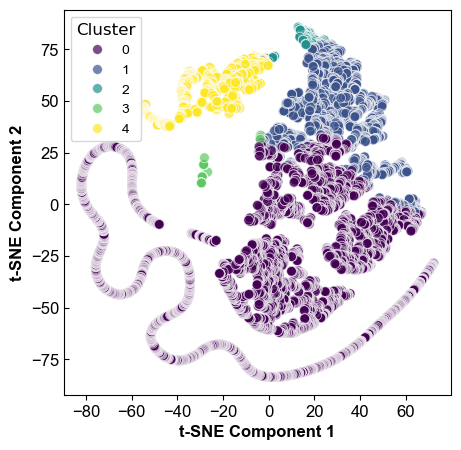

In [13]:
# Visualization using t-SNE on unscaled, scaled, and KPCA-transformed data
#tsne = TSNE(n_components=2, random_state=42, perplexity=15.0)

# Apply t-SNE to the unscaled data
#data_tsne_unscaled = tsne.fit_transform(data_numerical)
#tsne_unscaled_df = pd.DataFrame(data_tsne_unscaled, columns=['t-SNE1', 't-SNE2'])

# Apply t-SNE to the scaled data
tsne = TSNE(n_components=2, random_state=42, early_exaggeration=20, learning_rate='auto', perplexity=30)  # New instance for scaled data
data_tsne_scaled = tsne.fit_transform(scaled_data_numerical)
tsne_scaled_df = pd.DataFrame(data_tsne_scaled, columns=['t-SNE1', 't-SNE2'])

# Apply t-SNE to the kPCA-transformed data
#tsne = TSNE(n_components=2, random_state=42)  # New instance for kPCA data
#data_tsne_kpca = tsne.fit_transform(data_kpca_numerical)
#tsne_kpca_df = pd.DataFrame(data_tsne_kpca, columns=['t-SNE1', 't-SNE2'])

# Plotting the unscaled data with unscaled labels
#plt.figure(figsize=(4, 4))
#sns.scatterplot(data=tsne_unscaled_df, x='t-SNE1', y='t-SNE2', hue=kmeans_labels_unscaled, palette='viridis', s=50, alpha=0.7)
#plt.title('t-SNE Visualization of Unscaled Data', fontsize=12, fontname="Arial", fontweight="bold")
#plt.xlabel('t-SNE Component 1', fontsize=12, fontname="Arial", fontweight="bold")
#plt.ylabel('t-SNE Component 2', fontsize=12, fontname="Arial", fontweight="bold")
#plt.xticks(fontsize=12, fontname='Arial')
#plt.yticks(fontsize=12, fontname='Arial')
#plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
#plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
#plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\t-SNE Visualization of Unscaled Data with Unscaled Labels_k3_v6.jpeg", dpi=300, bbox_inches="tight")
#plt.show()

# Plotting the scaled data with scaled labels
plt.figure(figsize=(5, 5))
sns.scatterplot(data=tsne_scaled_df, x='t-SNE1', y='t-SNE2', hue=kmeans_labels_scaled, palette='viridis', s=50, alpha=0.7)
#plt.title('t-SNE Visualization of Z-Transform Scaled Data', fontsize=12, fontname="Arial", fontweight="bold")
plt.xlabel('t-SNE Component 1', fontsize=12, fontname="Arial", fontweight="bold")
plt.ylabel('t-SNE Component 2', fontsize=12, fontname="Arial", fontweight="bold")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
#plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\t-SNE Visualization of Scaled Data with Scaled Labels_k3_v6.jpeg", dpi=300, bbox_inches="tight")
plt.show()

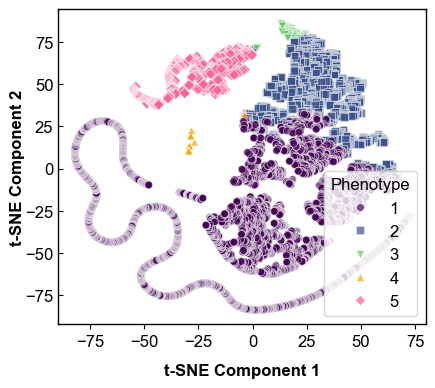

In [14]:
fig = plt.figure(figsize=(5.25, 4.5))  # 5" wide, 3.57" tall to make axes 2.5" high
ax = fig.add_axes([0.15, 0.15, 0.7, 0.7])  # Axes takes 70% of figure height

custom_palette = [
    (0.267004, 0.004874, 0.329415),  # dark purple
    (0.229739, 0.322361, 0.545706),  # blue
    (0.369214, 0.788888, 0.382914),  # green
    (255/255, 165/255, 0/255), #orange
    (249/255, 100/255, 149/255)  # pink
    # pink (instead of yellow)    
    
]

sns.scatterplot(
    data=tsne_scaled_df, x='t-SNE1', y='t-SNE2',
    hue=kmeans_labels_scaled,
    style=kmeans_labels_scaled,
    markers={0: 'o', 1: 's', 2: 'v', 3: '^', 4: 'D'},
    palette=custom_palette, s=30, alpha=0.7, ax=ax
)

# Get all handles and labels from the legend
handles, labels = ax.get_legend_handles_labels()

# Keep only numeric labels and their corresponding handles
cluster_items = [(h, int(l)) for h, l in zip(handles, labels) if l.isdigit()]

# Sort by cluster number (just in case)
cluster_items.sort(key=lambda x: x[1])

# Shift labels from 0-based to 1-based
new_handles = [h for h, _ in cluster_items]
new_labels = [str(i + 1) for _, i in cluster_items]

legend = ax.legend(
    handles=new_handles,
    labels=new_labels,
    title='Phenotype',
    loc="lower right",
    title_fontsize=12,
    prop={'family': 'Arial', 'size': 12}
)


# Now you can set the font name of the legend title
legend.get_title().set_fontname('Arial')

# Set axis labels
ax.set_xlabel('t-SNE Component 1', fontsize=12, fontname="Arial", fontweight="bold", labelpad=10)
ax.set_ylabel('t-SNE Component 2', fontsize=12, fontname="Arial", fontweight="bold", labelpad=0)
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')

# Set tick formatting
ax.tick_params(axis='y', direction='in', labelright=False, labelleft=True)

# Set spine linewidth to 1 pt
for spine in ax.spines.values():
    spine.set_linewidth(1)

# Legend
#ax.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})

# Save and show
plt.savefig(r"Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\7_Staph Dispersed Cells Figures\Plots\t-SNE Visualization of Scaled Data_k5_perplexity30.jpeg", dpi=300, bbox_inches="tight")
plt.show()

## Below this point is trial and error code

In [13]:
from sklearn.metrics import silhouette_score
silhouette_score = silhouette_score(data_tsne_unscaled, kmeans_labels_scaled)
print(silhouette_score)

0.061546974


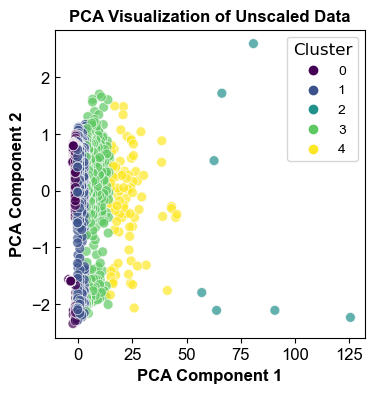

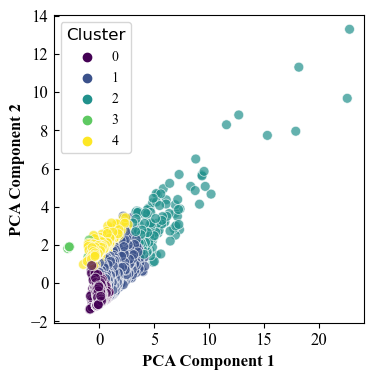

In [14]:
from sklearn.decomposition import PCA

# PCA for unscaled data
pca_unscaled = PCA(n_components=2, random_state=42)
data_pca_unscaled = pca_unscaled.fit_transform(data_numerical)
pca_unscaled_df = pd.DataFrame(data_pca_unscaled, columns=['PCA1', 'PCA2'])

# PCA for scaled data
pca_scaled = PCA(n_components=2, random_state=42)
data_pca_scaled = pca_scaled.fit_transform(scaled_data_numerical)
pca_scaled_df = pd.DataFrame(data_pca_scaled, columns=['PCA1', 'PCA2'])

# Visualization for unscaled data with unscaled labels
plt.figure(figsize=(4, 4))
sns.scatterplot(data=pca_unscaled_df, x='PCA1', y='PCA2', hue=kmeans_labels_unscaled, palette='viridis', s=50, alpha=0.7)
plt.title('PCA Visualization of Unscaled Data', fontsize=12, fontname="Arial", fontweight="bold")
plt.xlabel('PCA Component 1', fontsize=12, fontname="Arial", fontweight="bold")
plt.ylabel('PCA Component 2', fontsize=12, fontname="Arial", fontweight="bold")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
#plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\PCA Visualization of Unscaled Data with Unscaled Labels_k3_v6.jpeg", dpi=300, bbox_inches="tight")
plt.show()

# Visualization for scaled data with scaled labels
plt.figure(figsize=(4, 4))
sns.scatterplot(data=pca_scaled_df, x='PCA1', y='PCA2', hue=kmeans_labels_scaled, palette='viridis', s=50, alpha=0.7)
#plt.title('PCA Visualization of Z-Transform Scaled Data', fontsize=12, fontname="Times New Roman", fontweight="bold")
plt.xlabel('PCA Component 1', fontsize=12, fontname="Times New Roman", fontweight="bold")
plt.ylabel('PCA Component 2', fontsize=12, fontname="Times New Roman", fontweight="bold")
plt.xticks(fontsize=12, fontname='Times New Roman')
plt.yticks(fontsize=12, fontname='Times New Roman')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Times New Roman'})
#plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\PCA Visualization of Scaled Data with Scaled Labels_k3_v6.jpeg", dpi=300, bbox_inches="tight")
plt.show()

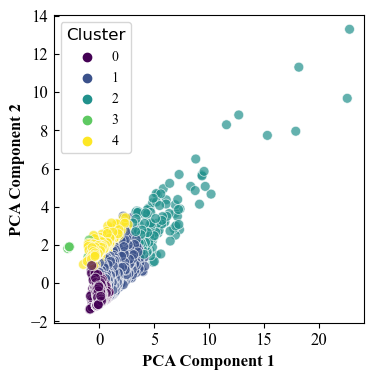

In [15]:
# Visualization for scaled data with scaled labels
plt.figure(figsize=(4, 4))
sns.scatterplot(data=pca_scaled_df, x='PCA1', y='PCA2', hue=kmeans_labels_scaled, palette='viridis', s=50, alpha=0.7)
#plt.title('PCA Visualization of Z-Transform Scaled Data', fontsize=12, fontname="Times New Roman", fontweight="bold")
plt.xlabel('PCA Component 1', fontsize=12, fontname="Times New Roman", fontweight="bold")
plt.ylabel('PCA Component 2', fontsize=12, fontname="Times New Roman", fontweight="bold")
plt.xticks(fontsize=12, fontname='Times New Roman')
plt.yticks(fontsize=12, fontname='Times New Roman')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Times New Roman'})
#plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\PCA Visualization of Scaled Data with Scaled Labels_k3_v6.jpeg", dpi=300, bbox_inches="tight")
plt.show()

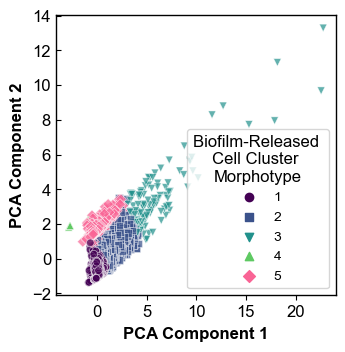

In [16]:
fig = plt.figure(figsize=(4, 4))  # 4" wide, 3.57" tall to make axes 2.5" high
ax = fig.add_axes([0.15, 0.15, 0.7, 0.7])  # Axes take up 70% of figure height

custom_palette = [
    (0.267004, 0.004874, 0.329415),  # dark purple
    (0.229739, 0.322361, 0.545706),  # blue
    (0.127568, 0.566949, 0.550556),  # turquoise
    (0.369214, 0.788888, 0.382914),  # green
    (249/255, 100/255, 149/255)   # pink (instead of yellow)
]

sns.scatterplot(
    data=pca_scaled_df, x='PCA1', y='PCA2',
    hue=kmeans_labels_scaled,
    style=kmeans_labels_scaled,
    markers={0: 'o', 1: 's', 2: 'v', 3: '^', 4: 'D'},
    palette=custom_palette, s=30, alpha=0.7, ax=ax
)

# Get all handles and labels from the legend
handles, labels = ax.get_legend_handles_labels()

# Keep only numeric labels and their corresponding handles
cluster_items = [(h, int(l)) for h, l in zip(handles, labels) if l.isdigit()]

# Sort by cluster number (just in case)
cluster_items.sort(key=lambda x: x[1])

# Shift labels from 0-based to 1-based
new_handles = [h for h, _ in cluster_items]
new_labels = [str(i + 1) for _, i in cluster_items]

# Create legend
legend = ax.legend(
    handles=new_handles,
    labels=new_labels,
    title='Biofilm-Released \nCell Cluster \nMorphotype',
    loc="lower right",
    fontsize=12,
    title_fontsize=12,
    prop={'family': 'Arial'},
)
legend.get_title().set_fontname('Arial')

# Set axis labels
ax.set_xlabel('PCA Component 1', fontsize=12, fontname="Arial", fontweight="bold", labelpad=5)
ax.set_ylabel('PCA Component 2', fontsize=12, fontname="Arial", fontweight="bold", labelpad=5)

# Tick labels
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')

# Tick formatting
ax.tick_params(axis='y', direction='in', labelright=False, labelleft=True)

# Set spine linewidth to 1 pt
for spine in ax.spines.values():
    spine.set_linewidth(1)
    
    legend.get_title().set_fontname('Arial')
    
# Left-align the labels in the legend
for text in legend.get_texts():
    text.set_ha('center')
    
# Also left-align the title
legend.get_title().set_ha('center')


# Save and show
plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\PCA Visualization of Scaled Data_k5_v1.jpeg", dpi=300, bbox_inches="tight")
plt.show()


In [17]:
# Visualization for scaled data with scaled labels
plt.figure(figsize=(4, 4))
sns.scatterplot(data=pca_scaled_df, x='PCA1', y='PCA2', hue=kmeans_labels_kpca, palette='viridis', s=50, alpha=0.7)
plt.title('PCA Visualization of Z-Transform Scaled Data with kPCA labels', fontsize=12, fontname="Arial", fontweight="bold")
plt.xlabel('PCA Component 1', fontsize=12, fontname="Arial", fontweight="bold")
plt.ylabel('PCA Component 2', fontsize=12, fontname="Arial", fontweight="bold")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\PCA Visualization of Scaled Data with kPCA Labels_k3_v6.jpeg", dpi=300, bbox_inches="tight")
plt.show()


NameError: name 'kmeans_labels_kpca' is not defined

<Figure size 400x400 with 0 Axes>

In [47]:
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
import pandas as pd

included_columns = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index", "Treatment"]
#columns = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index", "Treatment", "Date"]

# Assuming `data`, `data_scaled`, `columns`, `scaler`, and `Treatment` column are predefined
n_clusters = 5  # Number of clusters
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Extract scaling information
means = scaler.mean_
stds = scaler.scale_

# Define datasets and their names
datasets = {
    'Unscaled': (data_numerical, ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]),
    'Scaled': (scaled_data_numerical, ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]),
    # 'KPCA': (data_kpca_numerical, ["PC1", "PC2"]),  # Commented out KPCA dataset
}

# Store results for all datasets
all_results = {}

# Loop through each dataset
for dataset_name, (dataset, numerical_columns) in datasets.items():
    cluster_counts_table = pd.DataFrame()  # Table for cluster counts
    feature_stats_list = []  # Collect feature stats DataFrames for concatenation
    treatment_counts_list = []  # Collect treatment counts DataFrames for concatenation
    centroids_list = []  # Collect centroids DataFrames for concatenation

    # Perform 5-fold cross-validation
    for fold, (train_index, test_index) in enumerate(kf.split(dataset), start=1):
        train_data, test_data = dataset.iloc[train_index], dataset.iloc[test_index]

        # Ensure 'Treatment' and 'Date' columns are included in the dataset
        if 'Treatment' not in dataset.columns:
            dataset['Treatment'] = data.loc[dataset.index, 'Treatment']
        if 'Date' not in dataset.columns:
            dataset['Date'] = data.loc[dataset.index, 'Date']

        # Filter numerical columns for clustering
        numerical_columns = [
            col for col in numerical_columns
            if col in train_data.select_dtypes(include=['number']).columns
        ]
        if not numerical_columns:
            raise ValueError(f"No numerical columns found for dataset: {dataset_name}")

        # Perform k-means clustering on training data
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=fold)
        kmeans.fit(train_data[numerical_columns])

        # Assign cluster labels to test data
        test_labels = kmeans.predict(test_data[numerical_columns])

        # Create a temporary DataFrame for test data with labels
        test_df = test_data.copy()
        test_df['Cluster'] = test_labels

        # Calculate cluster sizes and add to cluster counts table
        cluster_sizes = test_df['Cluster'].value_counts(sort=False)
        cluster_counts_table[f'Fold {fold}'] = cluster_sizes

        # Calculate feature statistics and align cluster indices
        feature_stats = test_df.groupby('Cluster')[numerical_columns].agg(['mean', 'std', 'min', 'max'])
        feature_stats.columns = [f'{col}_{stat}' for col, stat in feature_stats.columns]
        feature_stats['Fold'] = f'Fold {fold}'  # Add fold identifier for later merging
        feature_stats['Cluster'] = feature_stats.index  # Preserve cluster index

        # Reverse scaling for scaled dataset
        if dataset_name == 'Scaled':
            for stat in ['mean', 'std', 'min', 'max']:
                for col in numerical_columns:
                    feature_stats[f'{col}_{stat}'] = (
                        feature_stats[f'{col}_{stat}'] * stds[included_columns.index(col)] + means[included_columns.index(col)]
                    )

            # Convert scaled data back to original dimensions
            test_df[numerical_columns] = test_df[numerical_columns] * stds + means

        # Reverse KPCA transformation if applicable
        # if dataset_name == 'KPCA':
        #     test_df[numerical_columns] = kpca.inverse_transform(test_df[numerical_columns].values)  # Commented out KPCA transformation

        feature_stats_list.append(feature_stats)

        # Calculate treatment counts and align cluster indices
    #    treatment_counts = test_df.groupby(['Cluster', 'Treatment']).size().unstack(fill_value=0)
     #   treatment_counts['Fold'] = f'Fold {fold}'  # Add fold identifier for later merging
      #  treatment_counts['Cluster'] = treatment_counts.index  # Preserve cluster index
       # treatment_counts_list.append(treatment_counts)

        # Add cluster centroids
        centroids_df = pd.DataFrame(kmeans.cluster_centers_, columns=numerical_columns)
        centroids_df['Cluster'] = centroids_df.index
        centroids_df['Fold'] = f'Fold {fold}'  # Add fold identifier for later merging

        # Reverse scaling for centroids in scaled dataset
        if dataset_name == 'Scaled':
            centroids_df[numerical_columns] = centroids_df[numerical_columns] * stds + means

        # Reverse KPCA transformation if applicable
        # if dataset_name == 'KPCA':
        #     centroids_df[included_columns] = kpca.inverse_transform(centroids_df[numerical_columns].values)  # Commented out KPCA transformation

        centroids_list.append(centroids_df)

    # Combine feature stats, treatment counts, and centroids across folds
    feature_stats_table = pd.concat(feature_stats_list, ignore_index=True).set_index(['Cluster', 'Fold'])
  #  treatment_counts_table = pd.concat(treatment_counts_list, ignore_index=True).set_index(['Cluster', 'Fold'])
    centroids_table = pd.concat(centroids_list, ignore_index=True).set_index(['Cluster', 'Fold'])

    # Store results for the current dataset
    all_results[dataset_name] = {
        'Cluster Counts': cluster_counts_table,
        'Feature Statistics': feature_stats_table,
       # 'Treatment Counts': treatment_counts_table,
        'Cluster Centroids': centroids_table,
    }

# Export results to Excel
output_path = r'C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Dispersed Cells Cluster Size and Morphology Data\fold_results_with_centroids_UnscaledScaledKPCA_v5.xlsx'

with pd.ExcelWriter(output_path) as writer:
    for dataset_name, results in all_results.items():
        # Write cluster counts
        results['Cluster Counts'].to_excel(writer, sheet_name=f'{dataset_name}_Cluster_Counts')

        # Write feature statistics
        results['Feature Statistics'].to_excel(writer, sheet_name=f'{dataset_name}_Feature_Stats')

        # Write treatment counts
     #   results['Treatment Counts'].to_excel(writer, sheet_name=f'{dataset_name}_Treatment_Counts')

        # Write cluster centroids
        results['Cluster Centroids'].to_excel(writer, sheet_name=f'{dataset_name}_Cluster_Centroids')

print(f"Fold results with cluster centroids for all datasets have been exported to '{output_path}'.")


OSError: Cannot save file into a non-existent directory: 'C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Dispersed Cells Cluster Size and Morphology Data'

In [49]:
scaled_data_numerical = scaled_data_numerical.drop(["Treatment", "Date"], axis=1)
print(scaled_data_numerical)

           N_cl  Euclid_2R  Shape_anisotropy_index  Asphericity_index
0     18.912448  16.531836                0.488576          -0.740624
1     15.551754  12.680603                0.327736          -0.405155
2     14.831606   9.831904               -0.053811           0.200487
3     21.793042   8.432682               -0.242612           1.848724
4      6.669923   7.741443                0.134550           0.162605
...         ...        ...                     ...                ...
9142  -0.771612  -1.340896               -2.687300           1.349973
9143  -0.771612  -1.340896               -2.687300           1.349973
9144  -0.771612  -1.340896               -2.687300           1.349973
9145  -0.771612  -1.340896               -2.687300           1.349973
9146  -0.771612  -1.340896               -2.687300           1.349973

[9147 rows x 4 columns]


In [50]:
print(scaled_data_numerical.dtypes)

N_cl                      float64
Euclid_2R                 float64
Shape_anisotropy_index    float64
Asphericity_index         float64
dtype: object


In [51]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Perform KMeans clustering with k=5.
kmeans = KMeans(n_clusters=5, random_state=42)
scaled_data_numerical['Cluster'] = kmeans.fit_predict(scaled_data_numerical)

# Merge the cluster assignments back to the original data.
data['Cluster'] = scaled_data_numerical['Cluster']

# Count the occurrences of each treatment per cluster for each date.
counts_per_date_cluster_treatment = (
    data.groupby(['Date', 'Cluster', 'Treatment']).size()
    .unstack(fill_value=0)  # Creates columns for each treatment with 0 as default.
)

# Export the results to Excel.
output_path = r"Z:\PhD Students\Packard_Sydney\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Dispersed Cells Cluster Size and Morphology Data\K-MeansResults_ReleasedCells_V3.xlsx"
with pd.ExcelWriter(output_path) as writer:
    # Export other results (if necessary).
    # cluster_stats.to_excel(writer, sheet_name="Cluster_Statistics")
    cluster_counts.to_excel(writer, sheet_name="Cluster_Counts")
    # data.to_excel(writer, sheet_name="Scaled_Data", index=False)
    # treatment_counts.to_excel(writer, sheet_name="Treatment_Counts")

    # Export the counts per date-cluster-treatment.
    counts_per_date_cluster_treatment.to_excel(writer, sheet_name="Counts_Per_Date_Cluster")

print(f"Export completed: '{output_path}' created.")


C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


IndexError: At least one sheet must be visible

In [53]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load the data
file_path = r"Z:\PhD Students\Packard_Sydney\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Combined_SizeMorphology_Data_v2.xlsx"
columns = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index", "Treatment", "Date"]
data = pd.read_excel(file_path, usecols=columns)

# Clean data and reset index for safety
data = data.dropna().reset_index(drop=True)

# 2. Scale and Cluster (k=5)
features = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(data[features])

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(x_scaled)

# 3. Explicitly define Treatment and Cluster Order
treatment_order = ["Untreated", "NaIO4", "ProtK", "DNaseI", "pH10"]
cluster_order = [1, 4, 2, 0, 3]

# Convert Treatment to a Categorical type to enforce your specific order
data['Treatment'] = pd.Categorical(data['Treatment'], categories=treatment_order, ordered=True)

# --- CALCULATIONS ---

# 4. Daily Replicate Stats (Counts and Percentages)
daily_counts = data.groupby(['Treatment', 'Date', 'Cluster'], observed=False).size().reset_index(name='Daily_Count')
daily_totals = daily_counts.groupby(['Treatment', 'Date'], observed=False)['Daily_Count'].transform('sum')
daily_counts['Daily_Percentage'] = (daily_counts['Daily_Count'] / daily_totals) * 100

# Calculate Mean, Std, and N across dates
rep_stats = daily_counts.groupby(['Treatment', 'Cluster'], observed=False).agg({
    'Daily_Percentage': ['mean', 'std', 'count'],
    'Daily_Count': ['mean']
})
rep_stats.columns = ['Avg_Pct_Across_Dates', 'Std_Pct_Across_Dates', 'N_Dates', 'Avg_Count_Across_Dates']
rep_stats = rep_stats.reset_index()

# 5. Pooled Treatment Totals (The "Total Percentage" single value)
treatment_sums = data.groupby(['Treatment', 'Cluster'], observed=False).size().reset_index(name='Total_Count_in_Cluster')
total_cells_per_treatment = treatment_sums.groupby('Treatment', observed=False)['Total_Count_in_Cluster'].transform('sum')
treatment_sums['Total_Treatment_Percentage'] = (treatment_sums['Total_Count_in_Cluster'] / total_cells_per_treatment) * 100

# 6. Merge everything
final_summary = pd.merge(treatment_sums, rep_stats, on=['Treatment', 'Cluster'])

# --- FORMATTING THE PIVOT TABLE ---

# 7. Create Pivot Table
# Values we want to see as sub-columns for each treatment
metrics = ['Total_Treatment_Percentage', 'Avg_Pct_Across_Dates', 'Std_Pct_Across_Dates', 'N_Dates']

pivot_table = final_summary.pivot(index='Cluster', columns='Treatment', values=metrics)

# Reorder Cluster Rows (1, 4, 2, 0, 3)
pivot_table = pivot_table.reindex(cluster_order)

# Reorder Treatment Columns (Untreated -> NaIO4 -> ProtK -> DNaseI -> pH10)
# We swap levels so Treatment is the top header
pivot_table = pivot_table.swaplevel(0, 1, axis=1)

# Ensure the columns follow the treatment_order explicitly
pivot_table = pivot_table.reindex(columns=treatment_order, level=0)

# 8. Export to Excel
output_path = r"Z:\PhD Students\Packard_Sydney\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Dispersed Cells Cluster Size and Morphology Data\K-MeansResults_Final_V5.xlsx"

with pd.ExcelWriter(output_path) as writer:
    pivot_table.to_excel(writer, sheet_name='Pivoted_Summary')
    final_summary.to_excel(writer, sheet_name='Detailed_Stats_List', index=False)
    # Include Cluster profiles to define what Cluster 1, 4, 2 etc. are
    data.groupby('Cluster')[features].mean().reindex(cluster_order).to_excel(writer, sheet_name='Cluster_Profiles')

print(f"Analysis complete! Data ordered by Treatment: {treatment_order}")
print(f"File saved to: {output_path}")

Analysis complete! Data ordered by Treatment: ['Untreated', 'NaIO4', 'ProtK', 'DNaseI', 'pH10']
File saved to: Z:\PhD Students\Packard_Sydney\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Dispersed Cells Cluster Size and Morphology Data\K-MeansResults_Final_V5.xlsx


In [ ]:
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
import pandas as pd

included_columns = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index", "Treatment"]
#columns = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index", "Treatment", "Date"]

# Assuming `data`, `data_scaled`, `columns`, `scaler`, and `Treatment` column are predefined
n_clusters = 5  # Number of clusters
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Extract scaling information
means = scaler.mean_
stds = scaler.scale_

# Define datasets and their names
datasets = {
   # 'Unscaled': (data_numerical, ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]),
   # 'Scaled': (scaled_data_numerical, ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]),
    'KPCA': (data_kpca_numerical, ["PC1", "PC2"]),  # Commented out KPCA dataset
}

# Store results for all datasets
all_results = {}

# Loop through each dataset
for dataset_name, (dataset, numerical_columns) in datasets.items():
    cluster_counts_table = pd.DataFrame()  # Table for cluster counts
    feature_stats_list = []  # Collect feature stats DataFrames for concatenation
    treatment_counts_list = []  # Collect treatment counts DataFrames for concatenation
    centroids_list = []  # Collect centroids DataFrames for concatenation

    # Perform 5-fold cross-validation
    for fold, (train_index, test_index) in enumerate(kf.split(dataset), start=1):
        train_data, test_data = dataset.iloc[train_index], dataset.iloc[test_index]

        # Ensure 'Treatment' and 'Date' columns are included in the dataset
        if 'Treatment' not in dataset.columns:
            dataset['Treatment'] = data.loc[dataset.index, 'Treatment']
        if 'Date' not in dataset.columns:
            dataset['Date'] = data.loc[dataset.index, 'Date']

        # Filter numerical columns for clustering
        numerical_columns = [
            col for col in numerical_columns
            if col in train_data.select_dtypes(include=['number']).columns
        ]
        if not numerical_columns:
            raise ValueError(f"No numerical columns found for dataset: {dataset_name}")

        # Perform k-means clustering on training data
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=fold)
        kmeans.fit(train_data[numerical_columns])

        # Assign cluster labels to test data
        test_labels = kmeans.predict(test_data[numerical_columns])

        # Create a temporary DataFrame for test data with labels
        test_df = test_data.copy()
        test_df['Cluster'] = test_labels

        # Calculate cluster sizes and add to cluster counts table
        cluster_sizes = test_df['Cluster'].value_counts(sort=False)
        cluster_counts_table[f'Fold {fold}'] = cluster_sizes

        # Calculate feature statistics and align cluster indices
        feature_stats = test_df.groupby('Cluster')[numerical_columns].agg(['mean', 'std', 'min', 'max'])
        feature_stats.columns = [f'{col}_{stat}' for col, stat in feature_stats.columns]
        feature_stats['Fold'] = f'Fold {fold}'  # Add fold identifier for later merging
        feature_stats['Cluster'] = feature_stats.index  # Preserve cluster index

        # Reverse scaling for scaled dataset
        #if dataset_name == 'Scaled':
         #   for stat in ['mean', 'std', 'min', 'max']:
          #      for col in numerical_columns:
           #         feature_stats[f'{col}_{stat}'] = (
            #            feature_stats[f'{col}_{stat}'] * stds[included_columns.index(col)] + means[included_columns.index(col)]
             #       )

            # Convert scaled data back to original dimensions
           # test_df[numerical_columns] = test_df[numerical_columns] * stds + means

        # Reverse KPCA transformation if applicable
        if dataset_name == 'KPCA':
            test_df[numerical_columns] = kpca.inverse_transform(test_df[numerical_columns].values)  # Commented out KPCA transformation

        feature_stats_list.append(feature_stats)

        # Calculate treatment counts and align cluster indices
        treatment_counts = test_df.groupby(['Cluster', 'Treatment']).size().unstack(fill_value=0)
        treatment_counts['Fold'] = f'Fold {fold}'  # Add fold identifier for later merging
        treatment_counts['Cluster'] = treatment_counts.index  # Preserve cluster index
        treatment_counts_list.append(treatment_counts)

        # Add cluster centroids
        centroids_df = pd.DataFrame(kmeans.cluster_centers_, columns=numerical_columns)
        centroids_df['Cluster'] = centroids_df.index
        centroids_df['Fold'] = f'Fold {fold}'  # Add fold identifier for later merging

        # Reverse scaling for centroids in scaled dataset
      #  if dataset_name == 'Scaled':
       #     centroids_df[numerical_columns] = centroids_df[numerical_columns] * stds + means

        # Reverse KPCA transformation if applicable
        if dataset_name == 'KPCA':
            centroids_df[included_columns] = kpca.inverse_transform(centroids_df[numerical_columns].values)  # Commented out KPCA transformation

        centroids_list.append(centroids_df)

    # Combine feature stats, treatment counts, and centroids across folds
    feature_stats_table = pd.concat(feature_stats_list, ignore_index=True).set_index(['Cluster', 'Fold'])
    treatment_counts_table = pd.concat(treatment_counts_list, ignore_index=True).set_index(['Cluster', 'Fold'])
    centroids_table = pd.concat(centroids_list, ignore_index=True).set_index(['Cluster', 'Fold'])

    # Store results for the current dataset
    all_results[dataset_name] = {
        'Cluster Counts': cluster_counts_table,
        'Feature Statistics': feature_stats_table,
        'Treatment Counts': treatment_counts_table,
        'Cluster Centroids': centroids_table,
    }

# Export results to Excel
output_path = r'C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Dispersed Cells Cluster Size and Morphology Data\fold_results_with_centroids_KPCA_v5.xlsx'

with pd.ExcelWriter(output_path) as writer:
    for dataset_name, results in all_results.items():
        # Write cluster counts
        results['Cluster Counts'].to_excel(writer, sheet_name=f'{dataset_name}_Cluster_Counts')

        # Write feature statistics
        results['Feature Statistics'].to_excel(writer, sheet_name=f'{dataset_name}_Feature_Stats')

        # Write treatment counts
        results['Treatment Counts'].to_excel(writer, sheet_name=f'{dataset_name}_Treatment_Counts')

        # Write cluster centroids
        results['Cluster Centroids'].to_excel(writer, sheet_name=f'{dataset_name}_Cluster_Centroids')

print(f"Fold results with cluster centroids for all datasets have been exported to '{output_path}'.")

In [ ]:
print(data_kpca_numerical.dtypes)
print(data_kpca_numerical.head())

In [ ]:
print("Original data length:", len(data))
print("Dataset length:", len(dataset))
print("Dataset indices match:", dataset.index.equals(data.index))
print("Columns in dataset:", dataset.columns)

In [ ]:
print(dataset.head())

In [ ]:
print(data.info())
print(data.dtypes)

numeric_data = data.select_dtypes(include=['number'])

In [ ]:
print(scaled_data_array)

In [ ]:
# K-Means Clustering
#numerical_columns = columns 
n_clusters = 5  # Define the number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_unscaled = kmeans.fit_predict(numerical_data)
kmeans_scaled = kmeans.fit_predict(scaled_data_array)
kmeans_kpca = kmeans.fit_predict(numerical_data_kpca)

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
from sklearn.cluster import KMeans

# Assuming `scaled_data_array`, `numerical_data_kpca`, `columns`, `features`, and `scaler` are predefined

# Initialize results dictionary
transformed_results = {}

# Convert scaled data array to DataFrame and add cluster labels
data_scaled_clustered = pd.DataFrame(scaled_data_array, columns=features.columns)
data_scaled_clustered['Cluster'] = kmeans_scaled  # Assuming `kmeans_scaled` contains the cluster labels

# Transform scaled data back to the original feature space
data_scaled_inverse = pd.DataFrame(
    scaler.inverse_transform(data_scaled_clustered[features.columns]),  # Only original features
    columns=features.columns  # Match original column names
)
data_scaled_inverse['Cluster'] = data_scaled_clustered['Cluster']  # Add cluster labels back
transformed_results['Scaled_Back_to_Original'] = data_scaled_inverse

# Convert KPCA-transformed data to DataFrame and add cluster labels
data_kpca_clustered = pd.DataFrame(
    numerical_data_kpca,
    columns=[f'PC{i+1}' for i in range(numerical_data_kpca.shape[1])]
)
data_kpca_clustered['Cluster'] = kmeans_kpca  # Assuming `kmeans_kpca` contains the cluster labels

# Transform KPCA data back to the original feature space if possible
try:
    data_kpca_inverse = pd.DataFrame(
        kpca.inverse_transform(data_kpca_clustered.iloc[:, :-1]),  # Exclude the Cluster column
        columns=features.columns  # Match original column names
    )
    data_kpca_inverse['Cluster'] = data_kpca_clustered['Cluster']  # Add cluster labels back
    transformed_results['KPCA_Back_to_Original'] = data_kpca_inverse
except NotImplementedError:
    print("Inverse transform is not available for the specified kernel in KernelPCA.")
    transformed_results['KPCA_Back_to_Original'] = None

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold

# Assuming 'data' is already defined and loaded

# Parameters
data_columns = data.columns  # Assume all columns are included initially
exclude_columns = ['Treatment', 'Date']  # List of column names to exclude from z-transform

# Separate excluded columns and apply z-transform
included_columns = [col for col in data_columns if col not in exclude_columns]
scaler = StandardScaler()
data_scaled_array = scaler.fit_transform(data[included_columns])  # Scale numeric columns

# Combine scaled data with the "Treatment" and "Date" columns
treatment_column = data['Treatment'].values.reshape(-1, 1)  # Ensure it is a 2D array
date_column = data['Date'].values.reshape(-1, 1)  # Ensure it is a 2D array
data_scaled_combined = np.hstack((data_scaled_array, treatment_column, date_column))

# Create a DataFrame with the original columns
data_scaled = pd.DataFrame(data_scaled_combined, columns=included_columns + exclude_columns)

# Extract features for PCA (ignoring the Treatment column)
features = data[["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]]

# Standardize the data
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply Kernel PCA with RBF kernel
kpca = KernelPCA(n_components=2, kernel="rbf", gamma=15, fit_inverse_transform=True)
features_kpca = kpca.fit_transform(features_scaled)

# Inverse transform the data
features_reconstructed = kpca.inverse_transform(features_kpca)

# Convert back to DataFrame for easy interpretation
data_kpca = pd.DataFrame(
    features_kpca,
    columns=["PC1", "PC2"]
)
reconstructed_df = pd.DataFrame(
    scaler.inverse_transform(features_reconstructed),
    columns=features.columns
)

data_kpca["Treatment"] = data["Treatment"]

# Perform k-means clustering with 5-fold cross-validation on the numerical columns of each data array
def perform_kmeans_cv(data_array, n_clusters=3):
    kmeans = KMeans(n_clusters=n_clusters)
    kf = KFold(n_splits=5)
    scores = cross_val_score(kmeans, data_array, cv=kf)
    return scores

# Perform k-means clustering on original data (excluding non-numeric columns)
original_scores = perform_kmeans_cv(data[included_columns])

# Perform k-means clustering on scaled data (excluding non-numeric columns)
scaled_scores = perform_kmeans_cv(data_scaled[included_columns])

# Perform k-means clustering on kpca transformed data (excluding non-numeric columns)
kpca_scores = perform_kmeans_cv(data_kpca[["PC1", "PC2"]])

print("Original Data CV Scores:", original_scores)
print("Scaled Data CV Scores:", scaled_scores)
print("KPCA Data CV Scores:", kpca_scores)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
import pandas as pd

included_columns = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]

# Assuming `data`, `data_scaled`, `data_kpca`, `columns`, `kpca_included_columns`, `scaler`, `kpca`, and `Treatment` column are predefined
n_clusters = 5  # Number of clusters
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Extract scaling information
means = scaler.mean_
stds = scaler.scale_

# Define datasets and their names
datasets = {
    'Unscaled': (numerical_data, columns),
    'Scaled': (numerical_data_scaled, columns),
    'KPCA': (numerical_data_kpca, kpca_included_columns),
}

# Store results for all datasets
all_results = {}

# Loop through each dataset
for dataset_name, (dataset, included_columns) in datasets.items():
    cluster_counts_table = pd.DataFrame()  # Table for cluster counts
    feature_stats_list = []  # Collect feature stats DataFrames for concatenation
    treatment_counts_list = []  # Collect treatment counts DataFrames for concatenation
    centroids_list = []  # Collect centroids DataFrames for concatenation

    # Perform 5-fold cross-validation
    for fold, (train_index, test_index) in enumerate(kf.split(dataset), start=1):
        train_data, test_data = dataset.iloc[train_index], dataset.iloc[test_index]

        # Perform k-means clustering on training data
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=fold)
        kmeans.fit(train_data.select_dtypes(include='number'))

        # Assign cluster labels to test data
        test_labels = kmeans.predict(test_data[included_columns])

        # Create a temporary DataFrame for test data with labels
        test_df = test_data.copy()
        test_df['Cluster'] = test_labels

        # Calculate cluster sizes and add to cluster counts table
        cluster_sizes = test_df['Cluster'].value_counts(sort=False)
        cluster_counts_table[f'Fold {fold}'] = cluster_sizes

        # Calculate feature statistics and align cluster indices
        feature_stats = test_df.groupby('Cluster')[included_columns].agg(['mean', 'std', 'min', 'max'])
        feature_stats.columns = [f'{col}_{stat}' for col, stat in feature_stats.columns]
        feature_stats['Fold'] = f'Fold {fold}'  # Add fold identifier for later merging
        feature_stats['Cluster'] = feature_stats.index  # Preserve cluster index

        # Reverse scaling for scaled dataset
        if dataset_name == 'Scaled':
            for stat in ['mean', 'std', 'min', 'max']:
                for col in included_columns:
                    feature_stats[f'{col}_{stat}'] = (
                        feature_stats[f'{col}_{stat}'] * stds[included_columns.index(col)] + means[included_columns.index(col)]
                    )

        feature_stats_list.append(feature_stats)

        # Calculate treatment counts and align cluster indices
        treatment_counts = test_df.groupby(['Cluster', 'Treatment']).size().unstack(fill_value=0)
        treatment_counts['Fold'] = f'Fold {fold}'  # Add fold identifier for later merging
        treatment_counts['Cluster'] = treatment_counts.index  # Preserve cluster index
        treatment_counts_list.append(treatment_counts)

        # Add cluster centroids
        centroids_df = pd.DataFrame(kmeans.cluster_centers_, columns=included_columns)
        centroids_df['Cluster'] = centroids_df.index
        centroids_df['Fold'] = f'Fold {fold}'  # Add fold identifier for later merging

        # Reverse scaling for centroids in scaled dataset
        if dataset_name == 'Scaled':
            centroids_df[included_columns] = centroids_df[included_columns] * stds + means

        # Reverse KPCA transformation if applicable
        if dataset_name == 'KPCA':
            centroids_df[included_columns] = KernelPCA.inverse_transform(centroids_df[included_columns].values)

        centroids_list.append(centroids_df)

    # Combine feature stats, treatment counts, and centroids across folds
    feature_stats_table = pd.concat(feature_stats_list, ignore_index=True).set_index(['Cluster', 'Fold'])
    treatment_counts_table = pd.concat(treatment_counts_list, ignore_index=True).set_index(['Cluster', 'Fold'])
    centroids_table = pd.concat(centroids_list, ignore_index=True).set_index(['Cluster', 'Fold'])

    # Store results for the current dataset
    all_results[dataset_name] = {
        'Cluster Counts': cluster_counts_table,
        'Feature Statistics': feature_stats_table,
        'Treatment Counts': treatment_counts_table,
        'Cluster Centroids': centroids_table,
    }

# Export results to Excel
output_path = r'C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Dispersed Cells Cluster Size and Morphology Data\fold_results_with_centroids_UnscaledScaledKPCA_v5.xlsx'

with pd.ExcelWriter(output_path) as writer:
    for dataset_name, results in all_results.items():
        # Write cluster counts
        results['Cluster Counts'].to_excel(writer, sheet_name=f'{dataset_name}_Cluster_Counts')

        # Write feature statistics
        results['Feature Statistics'].to_excel(writer, sheet_name=f'{dataset_name}_Feature_Stats')

        # Write treatment counts
        results['Treatment Counts'].to_excel(writer, sheet_name=f'{dataset_name}_Treatment_Counts')

        # Write cluster centroids
        results['Cluster Centroids'].to_excel(writer, sheet_name=f'{dataset_name}_Cluster_Centroids')

print(f"Fold results with cluster centroids for all datasets have been exported to '{output_path}'.")


In [ ]:
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
import pandas as pd

# Assuming `data`, `data_scaled`, `data_kpca`, `columns`, `kpca_included_columns`, and `Treatment` column are predefined
n_clusters = 5  # Number of clusters
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define datasets and their names
datasets = {
    'Unscaled': (data, columns),
    'Scaled': (data_scaled, columns),
    'KPCA': (data_kpca, kpca_included_columns),
}

# Store results for all datasets
all_results = {}

# Loop through each dataset
for dataset_name, (dataset, included_columns) in datasets.items():
    cluster_counts_table = pd.DataFrame()  # Table for cluster counts
    feature_stats_list = []  # Collect feature stats DataFrames for concatenation
    treatment_counts_list = []  # Collect treatment counts DataFrames for concatenation

    # Perform 5-fold cross-validation
    for fold, (train_index, test_index) in enumerate(kf.split(dataset), start=1):
        train_data, test_data = dataset.iloc[train_index], dataset.iloc[test_index]

        # Perform k-means clustering on training data
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=fold)
        kmeans.fit(train_data[included_columns])

        # Assign cluster labels to test data
        test_labels = kmeans.predict(test_data[included_columns])

        # Create a temporary DataFrame for test data with labels
        test_df = test_data.copy()
        test_df['Cluster'] = test_labels

        # Calculate cluster sizes and add to cluster counts table
        cluster_sizes = test_df['Cluster'].value_counts(sort=False)
        cluster_counts_table[f'Fold {fold}'] = cluster_sizes

        # Calculate feature statistics and align cluster indices
        feature_stats = test_df.groupby('Cluster')[included_columns].agg(['mean', 'std', 'min', 'max'])
        feature_stats.columns = [f'{col}_{stat}' for col, stat in feature_stats.columns]
        feature_stats['Fold'] = f'Fold {fold}'  # Add fold identifier for later merging
        feature_stats['Cluster'] = feature_stats.index  # Preserve cluster index
        feature_stats_list.append(feature_stats)

        # Calculate treatment counts and align cluster indices
        treatment_counts = test_df.groupby(['Cluster', 'Treatment']).size().unstack(fill_value=0)
        treatment_counts['Fold'] = f'Fold {fold}'  # Add fold identifier for later merging
        treatment_counts['Cluster'] = treatment_counts.index  # Preserve cluster index
        treatment_counts_list.append(treatment_counts)

    # Combine feature stats and treatment counts across folds
    feature_stats_table = pd.concat(feature_stats_list, ignore_index=True).set_index(['Cluster', 'Fold'])
    treatment_counts_table = pd.concat(treatment_counts_list, ignore_index=True).set_index(['Cluster', 'Fold'])

    # Store results for the current dataset
    all_results[dataset_name] = {
        'Cluster Counts': cluster_counts_table,
        'Feature Statistics': feature_stats_table,
        'Treatment Counts': treatment_counts_table,
    }

# Export results to Excel
output_path = r'C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Dispersed Cells Cluster Size and Morphology Data\fixed_combined_fold_results_UnscaledScaledKPCA_v3.xlsx'

with pd.ExcelWriter(output_path) as writer:
    for dataset_name, results in all_results.items():
        # Write cluster counts
        results['Cluster Counts'].to_excel(writer, sheet_name=f'{dataset_name}_Cluster_Counts')

        # Write feature statistics
        results['Feature Statistics'].to_excel(writer, sheet_name=f'{dataset_name}_Feature_Stats')

        # Write treatment counts
        results['Treatment Counts'].to_excel(writer, sheet_name=f'{dataset_name}_Treatment_Counts')

print(f"Fixed fold results for all datasets have been exported to '{output_path}'.")


In [83]:
# Define datasets and their names
datasets = {
    'Unscaled': (data, columns),
    'Scaled': (data_scaled, columns),
    'KPCA': (data_kpca, kpca_included_columns),
}

In [82]:
print(datasets['Scaled'])

(          N_cl Euclid_2R Shape_anisotropy_index Asphericity_index  Treatment  \
0     5.972351  1.074495              -0.015656          2.281198     DNaseI   
1     5.508193  0.999187               -1.13278          0.537284     DNaseI   
2     2.723247  0.604456               0.330239           0.12015     DNaseI   
3     2.723247  0.827712              -0.344108          0.169175     DNaseI   
4     2.491168  0.265261              -1.311838          1.832157     DNaseI   
...        ...       ...                    ...               ...        ...   
8447 -0.757936 -0.656814              -2.659668          1.356916  Untreated   
8448 -0.757936 -0.656814              -2.659668          1.356916  Untreated   
8449 -0.757936 -0.656814              -2.659668          1.356916  Untreated   
8450 -0.757936 -0.656814              -2.659668          1.356916  Untreated   
8451 -0.757936 -0.656814              -2.659668          1.356916  Untreated   

            Date  
0     04-23-2024  


In [ ]:
# Parameters
data_columns = data.columns  # Assume all columns are included initially
exclude_columns = ['Treatment']  # List of column names to exclude from z-transform

# Separate excluded columns and apply z-transform
included_columns = [col for col in data_columns if col not in exclude_columns]

In [44]:
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
import pandas as pd

# Assuming `data`, `data_scaled`, `data_kpca`, `columns`, `kpca_included_columns`, and `Treatment` column are predefined
n_clusters = 5  # Number of clusters
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define datasets and their names
datasets = {
    'Unscaled': (data, columns),
    'Scaled': (data_scaled, columns),
    'KPCA': (data_kpca, kpca_included_columns),
}

# Store results for all datasets
all_results = {}

# Loop through each dataset
for dataset_name, (dataset, included_columns) in datasets.items():
    cluster_counts_table = pd.DataFrame()  # Table for cluster counts
    feature_stats_list = []  # Collect feature stats DataFrames for concatenation
    treatment_counts_list = []  # Collect treatment counts DataFrames for concatenation
    centroids_list = []  # Collect centroids DataFrames for concatenation

    # Perform 5-fold cross-validation
    for fold, (train_index, test_index) in enumerate(kf.split(dataset), start=1):
        train_data, test_data = dataset.iloc[train_index], dataset.iloc[test_index]

        # Perform k-means clustering on training data
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=fold)
        kmeans.fit(train_data[included_columns])

        # Assign cluster labels to test data
        test_labels = kmeans.predict(test_data[included_columns])

        # Create a temporary DataFrame for test data with labels
        test_df = test_data.copy()
        test_df['Cluster'] = test_labels

        # Calculate cluster sizes and add to cluster counts table
        cluster_sizes = test_df['Cluster'].value_counts(sort=False)
        cluster_counts_table[f'Fold {fold}'] = cluster_sizes

        # Calculate feature statistics and align cluster indices
        feature_stats = test_df.groupby('Cluster')[included_columns].agg(['mean', 'std', 'min', 'max'])
        feature_stats.columns = [f'{col}_{stat}' for col, stat in feature_stats.columns]
        feature_stats['Fold'] = f'Fold {fold}'  # Add fold identifier for later merging
        feature_stats['Cluster'] = feature_stats.index  # Preserve cluster index
        feature_stats_list.append(feature_stats)

        # Calculate treatment counts and align cluster indices
        treatment_counts = test_df.groupby(['Cluster', 'Treatment']).size().unstack(fill_value=0)
        treatment_counts['Fold'] = f'Fold {fold}'  # Add fold identifier for later merging
        treatment_counts['Cluster'] = treatment_counts.index  # Preserve cluster index
        treatment_counts_list.append(treatment_counts)

        # Add cluster centroids
        centroids_df = pd.DataFrame(kmeans.cluster_centers_, columns=included_columns)
        centroids_df['Cluster'] = centroids_df.index
        centroids_df['Fold'] = f'Fold {fold}'  # Add fold identifier for later merging
        centroids_list.append(centroids_df)

    # Combine feature stats, treatment counts, and centroids across folds
    feature_stats_table = pd.concat(feature_stats_list, ignore_index=True).set_index(['Cluster', 'Fold'])
    treatment_counts_table = pd.concat(treatment_counts_list, ignore_index=True).set_index(['Cluster', 'Fold'])
    centroids_table = pd.concat(centroids_list, ignore_index=True).set_index(['Cluster', 'Fold'])

    # Store results for the current dataset
    all_results[dataset_name] = {
        'Cluster Counts': cluster_counts_table,
        'Feature Statistics': feature_stats_table,
        'Treatment Counts': treatment_counts_table,
        'Cluster Centroids': centroids_table,
    }

# Export results to Excel
output_path = r'C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Dispersed Cells Cluster Size and Morphology Data\fold_results_with_centroids_v4.xlsx'

with pd.ExcelWriter(output_path) as writer:
    for dataset_name, results in all_results.items():
        # Write cluster counts
        results['Cluster Counts'].to_excel(writer, sheet_name=f'{dataset_name}_Cluster_Counts')

        # Write feature statistics
        results['Feature Statistics'].to_excel(writer, sheet_name=f'{dataset_name}_Feature_Stats')

        # Write treatment counts
        results['Treatment Counts'].to_excel(writer, sheet_name=f'{dataset_name}_Treatment_Counts')

        # Write cluster centroids
        results['Cluster Centroids'].to_excel(writer, sheet_name=f'{dataset_name}_Cluster_Centroids')

print(f"Fold results with cluster centroids for all datasets have been exported to '{output_path}'.")


Fold results with cluster centroids for all datasets have been exported to 'C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Dispersed Cells Cluster Size and Morphology Data\fold_results_with_centroids_v4.xlsx'.


In [43]:
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
import pandas as pd

# Assuming `data`, `data_scaled`, `data_kpca`, `columns`, `kpca_included_columns`, and `Treatment` column are predefined
n_clusters = 5  # Number of clusters
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define datasets and their names
datasets = {
    'Unscaled': (data, columns),
    'Scaled': (data_scaled, columns),
    'KPCA': (data_kpca, kpca_included_columns),
}

# Function to align clusters based on a reference fold
def align_clusters(reference_centroids, current_centroids):
    # Calculate pairwise distances between reference and current centroids
    distances = cdist(reference_centroids, current_centroids, metric='euclidean')
    # Find the best alignment (minimize total distance)
    alignment = np.argmin(distances, axis=1)
    return alignment

# Store results for all datasets
all_results = {}

# Loop through each dataset
for dataset_name, (dataset, included_columns) in datasets.items():
    cluster_counts_table = pd.DataFrame()  # Table for cluster counts
    feature_stats_list = []  # Collect feature stats DataFrames for concatenation
    treatment_counts_list = []  # Collect treatment counts DataFrames for concatenation

    reference_centroids = None  # To store centroids of the first fold

# Ensure only numeric columns are used for clustering
included_columns = dataset.select_dtypes(include=[np.number]).columns

for fold, (train_index, test_index) in enumerate(kf.split(dataset), start=1):
    # Split into training and test sets
    train_data, test_data = dataset.iloc[train_index], dataset.iloc[test_index]

    # Ensure numeric data
    train_data = train_data[included_columns].fillna(0)
    test_data = test_data[included_columns].fillna(0)

    # Perform k-means clustering
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=fold)
    kmeans.fit(train_data)

        # Align clusters to the reference fold
        if fold == 1:
            reference_centroids = kmeans.cluster_centers_  # Set the reference centroids
            alignment = np.arange(n_clusters)  # Identity alignment for the first fold
        else:
            alignment = align_clusters(reference_centroids, kmeans.cluster_centers_)

        # Reorder cluster centroids based on alignment
        reordered_centroids = kmeans.cluster_centers_[alignment]

        # Predict cluster labels for the test data using reordered centroids
        test_labels = np.argmin(cdist(test_data[included_columns], reordered_centroids, metric='euclidean'), axis=1)

        # Create a DataFrame for the test data with aligned cluster labels
        test_df = test_data.copy()
        test_df['Cluster'] = test_labels

        # Calculate cluster sizes and add to cluster counts table
        cluster_sizes = test_df['Cluster'].value_counts(sort=False)
        cluster_counts_table[f'Fold {fold}'] = cluster_sizes.sort_index()

        # Calculate feature statistics and align cluster indices
        feature_stats = test_df.groupby('Cluster')[included_columns].agg(['mean', 'std', 'min', 'max'])
        feature_stats.columns = [f'{col}_{stat}' for col, stat in feature_stats.columns]
        feature_stats['Fold'] = f'Fold {fold}'  # Add fold identifier for later merging
        feature_stats['Cluster'] = feature_stats.index  # Preserve cluster index
        feature_stats_list.append(feature_stats)

        # Calculate treatment counts and align cluster indices
        treatment_counts = test_df.groupby(['Cluster', 'Treatment']).size().unstack(fill_value=0)
        treatment_counts['Fold'] = f'Fold {fold}'  # Add fold identifier for later merging
        treatment_counts['Cluster'] = treatment_counts.index  # Preserve cluster index
        treatment_counts_list.append(treatment_counts)

    # Combine feature stats and treatment counts across folds
    feature_stats_table = pd.concat(feature_stats_list, ignore_index=True).set_index(['Cluster', 'Fold'])
    treatment_counts_table = pd.concat(treatment_counts_list, ignore_index=True).set_index(['Cluster', 'Fold'])

    # Store results for the current dataset
    all_results[dataset_name] = {
        'Cluster Counts': cluster_counts_table,
        'Feature Statistics': feature_stats_table,
        'Treatment Counts': treatment_counts_table,
    }

# Export results to Excel
output_path = r'C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Dispersed Cells Cluster Size and Morphology Data\aligned_fold_results_UnscaledScaledKPCA_v4.xlsx'


with pd.ExcelWriter(output_path) as writer:
    for dataset_name, results in all_results.items():
        # Write cluster counts
        results['Cluster Counts'].to_excel(writer, sheet_name=f'{dataset_name}_Cluster_Counts')

        # Write feature statistics
        results['Feature Statistics'].to_excel(writer, sheet_name=f'{dataset_name}_Feature_Stats')

        # Write treatment counts
        results['Treatment Counts'].to_excel(writer, sheet_name=f'{dataset_name}_Treatment_Counts')

print(f"Aligned fold results for all datasets have been exported to '{output_path}'.")


KeyError: 'Treatment'

In [50]:
# K-Means Clustering
 
n_clusters = 5  # Define the number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)


# Generate cluster labels
data['Cluster_Unscaled'] = kmeans.fit_predict(data_numerical)
data_scaled['Cluster_Scaled'] = kmeans.fit_predict(scaled_data_numerical)
data_kpca['Cluster_kPCA'] = kmeans.fit_predict(data_kpca_numerical)

# Generate statistics for numeric data
def calculate_cluster_statistics(data, cluster_column, numeric_columns):
    # Aggregate numeric columns only
    stats = (
        data.groupby(cluster_column)[numeric_columns]
        .agg(['mean', 'std', 'min', 'max', 'count'])
        .sort_values(by=(numeric_columns[0], 'count'), ascending=False)
    )
    return stats

# Count treatments per cluster
def count_treatments(data, cluster_column):
    return (
        data.groupby(cluster_column)['Treatment']
        .value_counts()
        .unstack(fill_value=0)  # Create a pivot table with counts for each treatment
    )

# Specify numeric columns
numeric_columns = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]

# Calculate cluster statistics for each dataset
stats_unscaled = calculate_cluster_statistics(data, 'Cluster_Unscaled', numeric_columns)
stats_scaled = calculate_cluster_statistics(data_scaled, 'Cluster_Scaled', numeric_columns)
stats_kpca = calculate_cluster_statistics(data_kpca, 'Cluster_kPCA', numeric_columns)

# Count treatments for each dataset
treatment_counts_unscaled = count_treatments(data, 'Cluster_Unscaled')
treatment_counts_scaled = count_treatments(data_scaled, 'Cluster_Scaled')
treatment_counts_kpca = count_treatments(data_kpca, 'Cluster_kPCA')

# Export to Excel
output_path = output_path = r'C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Biofilms and Machine Learning\cluster_stats_all_TreatmentDistributions.xlsx'
with pd.ExcelWriter(output_path) as writer:
    stats_unscaled.to_excel(writer, sheet_name='Unscaled_Stats')
    stats_scaled.to_excel(writer, sheet_name='Scaled_Stats')
    stats_kpca.to_excel(writer, sheet_name='kPCA_Stats')
    
    treatment_counts_unscaled.to_excel(writer, sheet_name='Unscaled_Treatments')
    treatment_counts_scaled.to_excel(writer, sheet_name='Scaled_Treatments')
    treatment_counts_kpca.to_excel(writer, sheet_name='kPCA_Treatments')

print(f"Cluster statistics and treatment counts exported to '{output_path}'!")


C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KeyError: "Columns not found: 'Shape_anisotropy_index', 'Euclid_2R', 'N_cl', 'Asphericity_index'"

In [23]:
import pandas as pd
from sklearn.cluster import KMeans

# Define the treatment conditions
treatment_conditions = ["Untreated", "NaIO4", "Proteinase_K", "DNase", "pH_10"]

# K-Means Clustering
n_clusters = 5  # Define the number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Generate cluster labels
data['Cluster_Unscaled'] = kmeans.fit_predict(data[included_columns])
data_scaled['Cluster_Scaled'] = kmeans.fit_predict(data_scaled[included_columns])
#data_kpca['Cluster_kPCA'] = kmeans.fit_predict(data_kpca[included_columns])

# Count treatments per cluster for each dataset
def count_treatments(data, cluster_column):
    return (
        data.groupby(cluster_column)['Treatment']
        .value_counts()
        .unstack(fill_value=0)  # Create a pivot table with counts for each treatment
    )

# Perform grouping and count treatments
treatment_counts_unscaled = count_treatments(data, 'Cluster_Unscaled')
treatment_counts_scaled = count_treatments(data_scaled, 'Cluster_Scaled')
#treatment_counts_kpca = count_treatments(data_kpca, 'Cluster_kPCA')

# Generate statistics for numeric data
def calculate_cluster_statistics(data, cluster_column):
    return (
        data.groupby(cluster_column)
        .agg(['mean', 'std', 'min', 'max', 'count'])
        .sort_values(by=(numerical_columns[0], 'count'), ascending=False)
    )

stats_unscaled = calculate_cluster_statistics(data, 'Cluster_Unscaled')
stats_scaled = calculate_cluster_statistics(data_scaled, 'Cluster_Scaled')
#stats_kpca = calculate_cluster_statistics(data_kpca, 'Cluster_kPCA')

# Export statistics and treatment counts to Excel
output_path = r'C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Biofilms and Machine Learning\cluster_stats_all_TreatmentDistributions.xlsx'
with pd.ExcelWriter(output_path) as writer:
    stats_unscaled.to_excel(writer, sheet_name='Unscaled_Stats')
    stats_scaled.to_excel(writer, sheet_name='Scaled_Stats')
    #stats_kpca.to_excel(writer, sheet_name='kPCA_Stats')
    
    treatment_counts_unscaled.to_excel(writer, sheet_name='Unscaled_Treatments')
    treatment_counts_scaled.to_excel(writer, sheet_name='Scaled_Treatments')
   # treatment_counts_kpca.to_excel(writer, sheet_name='kPCA_Treatments')

print(f"Cluster statistics and treatment counts exported to '{output_path}'!")


C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


TypeError: Could not convert pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10pH_10p

In [27]:
# K-Means Clustering
numerical_columns = columns 
n_clusters = 5  # Define the number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels_unscaled = kmeans.fit_predict(data[included_columns])
kmeans_labels_scaled = kmeans.fit_predict(data_scaled[included_columns])
kmeans_labels_kpca = kmeans.fit_predict(data_kpca[kpca_included_columns])

# Generate cluster labels
data['Cluster_Unscaled'] = kmeans.fit_predict(data[included_columns])
data_scaled['Cluster_Scaled'] = kmeans.fit_predict(data_scaled[included_columns])
data_kpca['Cluster_kPCA'] = kmeans.fit_predict(data_kpca[kpca_included_columns])

columns = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]

# Filter numeric_data to include only the specified columns
filtered_data = numeric_data[columns]

# Perform grouping and statistics for each set of labels
stats_scaled = filtered_data.groupby(data['Cluster_Unscaled']).agg(['mean', 'std', 'min', 'max', 'count'])
stats_unscaled = filtered_data.groupby(data_scaled['Cluster_Scaled']).agg(['mean', 'std', 'min', 'max', 'count'])
stats_kpca = filtered_data.groupby(data_kpca['Cluster_kPCA']).agg(['mean', 'std', 'min', 'max', 'count'])

# Sort by count for each dataset
stats_scaled = stats_scaled.sort_values(by=(columns[0], 'count'), ascending=False)
stats_unscaled = stats_unscaled.sort_values(by=(columns[0], 'count'), ascending=False)
stats_kpca = stats_kpca.sort_values(by=(columns[0], 'count'), ascending=False)

# Export to a single Excel file with multiple sheets
output_path = r'C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Dispersed Cells Cluster Size and Morphology Data\cluster_stats_all_k5.xlsx'
with pd.ExcelWriter(output_path) as writer:
    stats_scaled.to_excel(writer, sheet_name='Scaled')
    stats_unscaled.to_excel(writer, sheet_name='Unscaled')
    stats_kpca.to_excel(writer, sheet_name='kPCA')

print(f"Cluster statistics exported to '{output_path}'!")


C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Cluster statistics exported to 'C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Dispersed Cells Cluster Size and Morphology Data\cluster_stats_all_k5.xlsx'!


In [30]:
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold

# Assuming `data_scaled`, `training_data`, `scaler`, and `columns` are predefined
num_clusters = 5  # Adjust the number of clusters if needed
kf = KFold(n_splits=5, shuffle=True, random_state=42)

array = data['Cluster_Unscaled']

# Dictionary to store fold-specific results
fold_results = {}

for fold, (train_index, test_index) in enumerate(kf.split(array), start=1):
    train_data, test_data = array[train_index], array[test_index]

    # Perform k-means clustering on training data
    kmeans = KMeans(n_clusters=num_clusters, n_init=10, random_state=fold)
    kmeans.fit(train_data)

    # Assign cluster labels to test data
    test_labels = kmeans.predict(test_data)

    # Create a temporary DataFrame for test data with labels
    test_df = training_data.iloc[test_index].copy()
    test_df['Cluster'] = test_labels

    # Calculate cluster sizes
    cluster_sizes = test_df['Cluster'].value_counts(sort=False)

    # Calculate feature statistics (mean, std, min, max) per cluster
    feature_stats = test_df.groupby('Cluster')[columns].agg(['mean', 'std', 'min', 'max'])

    # Count treatment conditions within each cluster
    treatment_counts = test_df.groupby(['Cluster', 'Treatment']).size().unstack(fill_value=0)

    # Store results for the current fold
    fold_results[f'Fold_{fold}'] = {
        'Cluster Sizes': cluster_sizes,
        'Feature Statistics': feature_stats,
        'Treatment Counts': treatment_counts
    }

# Export fold-specific results to Excel
output_path = r'C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Dispersed Cells Cluster Size and Morphology Data\fold_specific_cluster_results_Unscaled.xlsx'

with pd.ExcelWriter(output_path) as writer:
    for fold, results in fold_results.items():
        # Export cluster sizes
        results['Cluster Sizes'].to_excel(writer, sheet_name=f'{fold}_Cluster_Sizes')

        # Export feature statistics
        results['Feature Statistics'].to_excel(writer, sheet_name=f'{fold}_Feature_Statistics')

        # Export treatment counts
        results['Treatment Counts'].to_excel(writer, sheet_name=f'{fold}_Treatment_Counts')

print(f"Fold-specific results (cluster sizes, feature statistics, and treatment counts) have been exported to '{output_path}'.")


ValueError: Expected 2D array, got 1D array instead:
array=[4. 2. 4. ... 3. 3. 3.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [45]:
scaled_data_numerical = data_scaled.drop(["Treatment", "Date"], axis=1)
print(scaled_data_numerical)
data_numerical = data.drop(["Treatment", "Date"], axis = 1) 
print(data_numerical)

          N_cl Euclid_2R Shape_anisotropy_index Asphericity_index
0     5.972351  1.074495              -0.015656          2.281198
1     5.508193  0.999187               -1.13278          0.537284
2     2.723247  0.604456               0.330239           0.12015
3     2.723247  0.827712              -0.344108          0.169175
4     2.491168  0.265261              -1.311838          1.832157
...        ...       ...                    ...               ...
8447 -0.757936 -0.656814              -2.659668          1.356916
8448 -0.757936 -0.656814              -2.659668          1.356916
8449 -0.757936 -0.656814              -2.659668          1.356916
8450 -0.757936 -0.656814              -2.659668          1.356916
8451 -0.757936 -0.656814              -2.659668          1.356916

[8452 rows x 4 columns]
      N_cl  Euclid_2R  Shape_anisotropy_index  Asphericity_index
0       30   4.873922                0.834579           0.835471
1       28   4.692364                0.481960        

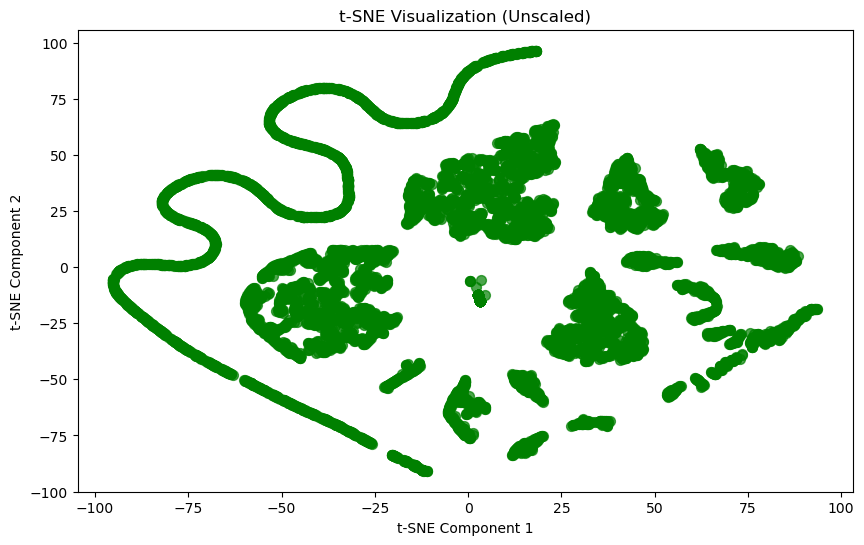

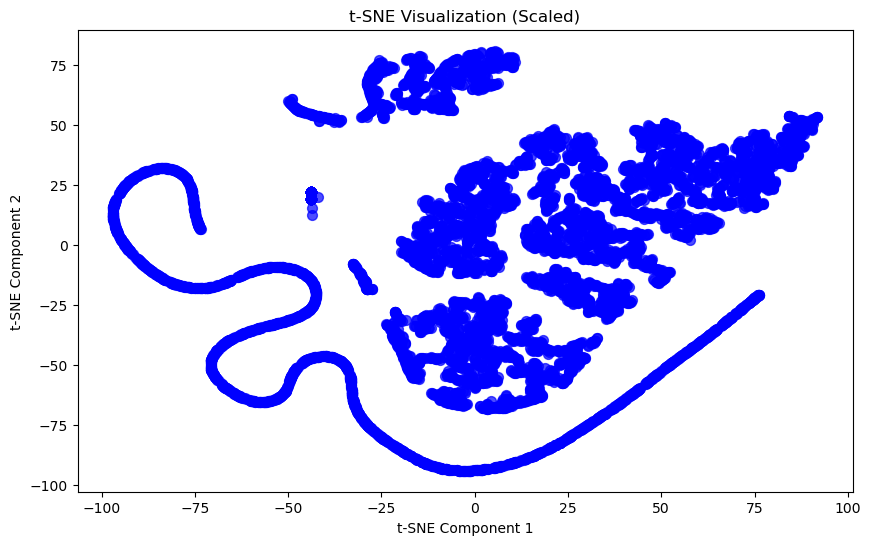

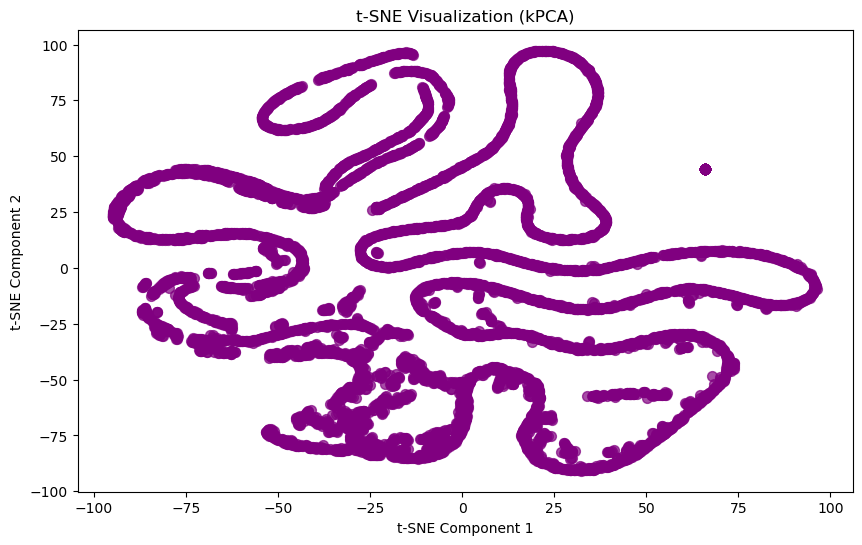

In [16]:
# Step 1: Apply t-SNE to reduce the dimensionality of data
tsne = TSNE(n_components=2, random_state=42)
tsne_unscaled = tsne.fit_transform(data_numerical)

# Step 2: Plot the t-SNE results without labels
plt.figure(figsize=(10, 6))
plt.scatter(tsne_unscaled[:, 0], tsne_unscaled[:, 1], s=50, alpha=0.7, color='green')
plt.title("t-SNE Visualization (Unscaled)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

# Step 1: Apply t-SNE to reduce the dimensionality of data
tsne = TSNE(n_components=2, random_state=42)
tsne_scaled = tsne.fit_transform(scaled_data_numerical)

# Step 2: Plot the t-SNE results without labels
plt.figure(figsize=(10, 6))
plt.scatter(tsne_scaled[:, 0], tsne_scaled[:, 1], s=50, alpha=0.7, color='blue')
plt.title("t-SNE Visualization (Scaled)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

# Step 1: Apply t-SNE to reduce the dimensionality of data
tsne = TSNE(n_components=2, random_state=42)
tsne_kpca = tsne.fit_transform(data_kpca_numerical)

# Step 2: Plot the t-SNE results without labels
plt.figure(figsize=(10, 6))
plt.scatter(tsne_kpca[:, 0], tsne_kpca[:, 1], s=50, alpha=0.7, color='purple')
plt.title("t-SNE Visualization (kPCA)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

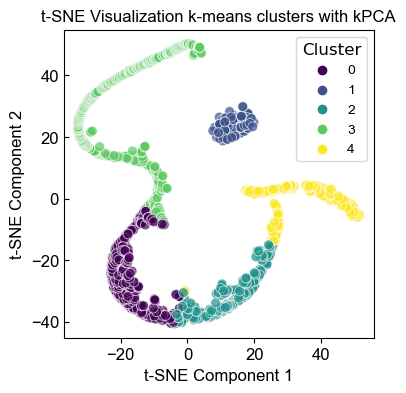

In [11]:
# Visualization using t-SNE
tsne = TSNE(n_components=2, random_state=42)
data_tsne_kpca = tsne.fit_transform(data_kpca_numerical)
tsne_df_kpca = pd.DataFrame(data_tsne_kpca, columns=['t-SNE1', 't-SNE2'])
#tsne_df_kpca['Cluster'] = kpca_df['Cluster']

plt.figure(figsize=(4, 4))
sns.scatterplot(data=tsne_df_kpca, x='t-SNE1', y='t-SNE2', hue=kmeans_labels_kpca, palette='viridis', s=50, alpha=0.7)
plt.title('t-SNE Visualization k-means clusters with kPCA', fontsize=12, fontname="Arial")
plt.xlabel('t-SNE Component 1', fontsize=12, fontname="Arial")
plt.ylabel('t-SNE Component 2', fontsize=12, fontname="Arial")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
#plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\t-SNE Visualization of Clusters.jpeg", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
# K-Means Clustering
n_clusters = 5  # Define the number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels_unscaled = kmeans.fit_predict(data_numerical)
kmeans_labels_scaled = kmeans.fit_predict(scaled_data_numerical)
kmeans_labels_kpca = kmeans.fit_predict(data_kpca_numerical)

new_labels = [str(int(label) + 1) for label in labels if label.isdigit()]

kmeans_labels_unscaled = [str(int(kmeans_labels_unscaled) + 1) for kmeans_labels_unscaled in labels if label.isdigit()]
kmeans_labels_scaled = kmeans.fit_predict(scaled_data_numerical)
kmeans_labels_kpca = kmeans.fit_predict(data_kpca_numerical)

#kpca_df['Cluster'] = kmeans.fit_predict(data)

C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


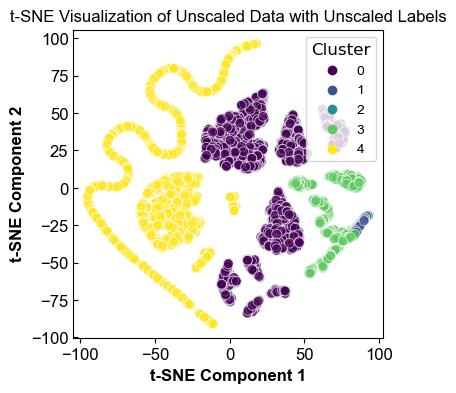

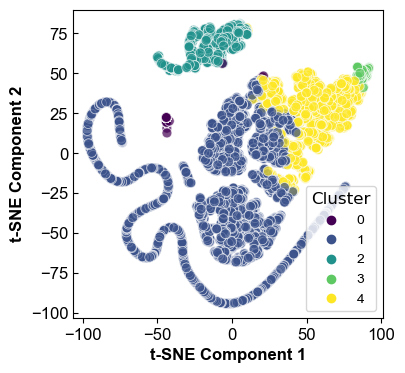

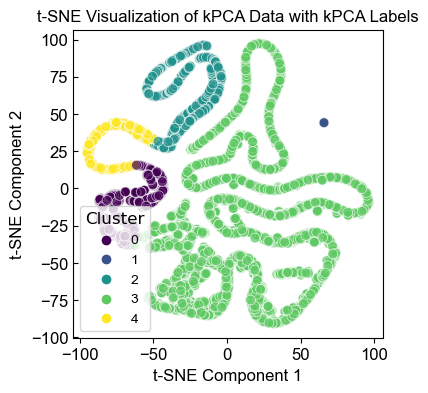

In [18]:
# Visualization using t-SNE on unscaled, scaled, and KPCA-transformed data
tsne = TSNE(n_components=2, random_state=42)

# Apply t-SNE to the unscaled data
data_tsne_unscaled = tsne.fit_transform(data_numerical)
tsne_unscaled_df = pd.DataFrame(data_tsne_unscaled, columns=['t-SNE1', 't-SNE2'])

# Apply t-SNE to the scaled data
tsne = TSNE(n_components=2, random_state=42)  # New instance for scaled data
data_tsne_scaled = tsne.fit_transform(scaled_data_numerical)
tsne_scaled_df = pd.DataFrame(data_tsne_scaled, columns=['t-SNE1', 't-SNE2'])

# Apply t-SNE to the kPCA-transformed data
tsne = TSNE(n_components=2, random_state=42)  # New instance for kPCA data
data_tsne_kpca = tsne.fit_transform(data_kpca_numerical)
tsne_kpca_df = pd.DataFrame(data_tsne_kpca, columns=['t-SNE1', 't-SNE2'])

new_labels = [str(int(label) + 1) for label in labels if label.isdigit()]

# Plotting the unscaled data with unscaled labels
plt.figure(figsize=(4, 4))
sns.scatterplot(data=tsne_unscaled_df, x='t-SNE1', y='t-SNE2', hue=kmeans_labels_unscaled, palette='viridis', s=50, alpha=0.7)
plt.title('t-SNE Visualization of Unscaled Data with Unscaled Labels', fontsize=12, fontname="Arial")
plt.xlabel('t-SNE Component 1', fontsize=12, fontname="Arial", fontweight='bold')
plt.ylabel('t-SNE Component 2', fontsize=12, fontname="Arial", fontweight='bold')
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
#plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\t-SNE Visualization of Unscaled Data with Unscaled Labels_k5_ZerosAdded_v1.jpeg", dpi=300, bbox_inches="tight")
plt.show()

# Plotting the scaled data with scaled labels
plt.figure(figsize=(4, 4))
sns.scatterplot(data=tsne_scaled_df, x='t-SNE1', y='t-SNE2', hue=kmeans_labels_scaled, palette='viridis', s=50, alpha=0.7)
#plt.title('t-SNE Visualization of Scaled Data with Scaled Labels', fontsize=12, fontname="Arial")
plt.xlabel('t-SNE Component 1', fontsize=12, fontname="Arial", fontweight='bold')
plt.ylabel('t-SNE Component 2', fontsize=12, fontname="Arial", fontweight='bold')
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\t-SNE Visualization of Scaled Data with Scaled Labels_k5_ZerosAdded_v1.jpeg", dpi=300, bbox_inches="tight")
plt.show()

# Plotting the kPCA data with kPCA labels
plt.figure(figsize=(4, 4))
sns.scatterplot(data=tsne_kpca_df, x='t-SNE1', y='t-SNE2', hue=kmeans_labels_kpca, palette='viridis', s=50, alpha=0.7)
plt.title('t-SNE Visualization of kPCA Data with kPCA Labels', fontsize=12, fontname="Arial")
plt.xlabel('t-SNE Component 1', fontsize=12, fontname="Arial")
plt.ylabel('t-SNE Component 2', fontsize=12, fontname="Arial")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
#plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\t-SNE Visualization of kPCA Data with kPCA Labels_k5_ZerosAdded_v1.jpeg", dpi=300, bbox_inches="tight")
plt.show()


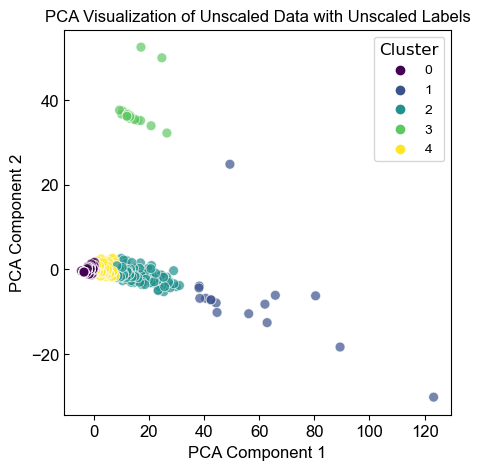

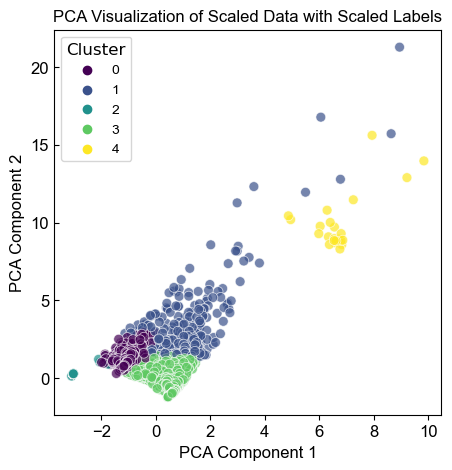

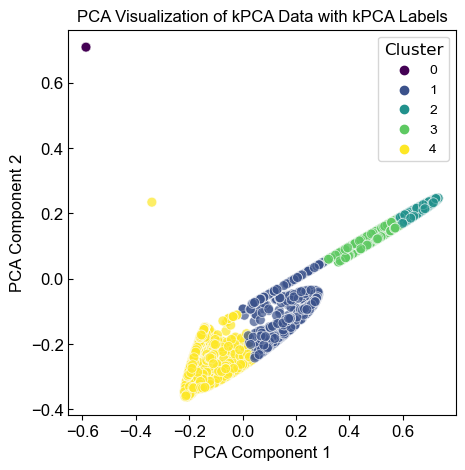

In [52]:
from sklearn.decomposition import PCA

# PCA for unscaled data
pca_unscaled = PCA(n_components=2, random_state=42)
data_pca_unscaled = pca_unscaled.fit_transform(data_numerical)
pca_unscaled_df = pd.DataFrame(data_pca_unscaled, columns=['PCA1', 'PCA2'])

# PCA for scaled data
pca_scaled = PCA(n_components=2, random_state=42)
data_pca_scaled = pca_scaled.fit_transform(scaled_data_numerical)
pca_scaled_df = pd.DataFrame(data_pca_scaled, columns=['PCA1', 'PCA2'])

# PCA for kPCA-transformed data
pca_kpca = PCA(n_components=2, random_state=42)
data_pca_kpca = pca_kpca.fit_transform(data_kpca_numerical)
pca_kpca_df = pd.DataFrame(data_pca_kpca, columns=['PCA1', 'PCA2'])

# Visualization for unscaled data with unscaled labels
plt.figure(figsize=(5, 5))
sns.scatterplot(data=pca_unscaled_df, x='PCA1', y='PCA2', hue=kmeans_labels_unscaled, palette='viridis', s=50, alpha=0.7)
plt.title('PCA Visualization of Unscaled Data with Unscaled Labels', fontsize=12, fontname="Arial")
plt.xlabel('PCA Component 1', fontsize=12, fontname="Arial")
plt.ylabel('PCA Component 2', fontsize=12, fontname="Arial")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\PCA Visualization of Unscaled Data with Unscaled Labels_k5_ZerosAdded_v1.jpeg", dpi=300, bbox_inches="tight")
plt.show()

# Visualization for scaled data with scaled labels
plt.figure(figsize=(5, 5))
sns.scatterplot(data=pca_scaled_df, x='PCA1', y='PCA2', hue=kmeans_labels_scaled, palette='viridis', s=50, alpha=0.7)
plt.title('PCA Visualization of Scaled Data with Scaled Labels', fontsize=12, fontname="Arial")
plt.xlabel('PCA Component 1', fontsize=12, fontname="Arial")
plt.ylabel('PCA Component 2', fontsize=12, fontname="Arial")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\PCA Visualization of Scaled Data with Scaled Labels_k5_ZerosAdded_v1.jpeg", dpi=300, bbox_inches="tight")
plt.show()

# Visualization for kPCA-transformed data with kPCA labels
plt.figure(figsize=(5, 5))
sns.scatterplot(data=pca_kpca_df, x='PCA1', y='PCA2', hue=kmeans_labels_kpca, palette='viridis', s=50, alpha=0.7)
plt.title('PCA Visualization of kPCA Data with kPCA Labels', fontsize=12, fontname="Arial")
plt.xlabel('PCA Component 1', fontsize=12, fontname="Arial")
plt.ylabel('PCA Component 2', fontsize=12, fontname="Arial")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\PCA Visualization of kPCA Data with kPCA Labels_k5_ZerosAdded_v1.jpeg", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarni

C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarni

Optimal k for unscaled data: 5
Optimal k for scaled data: 5
Optimal k for kPCA-transformed data: 4


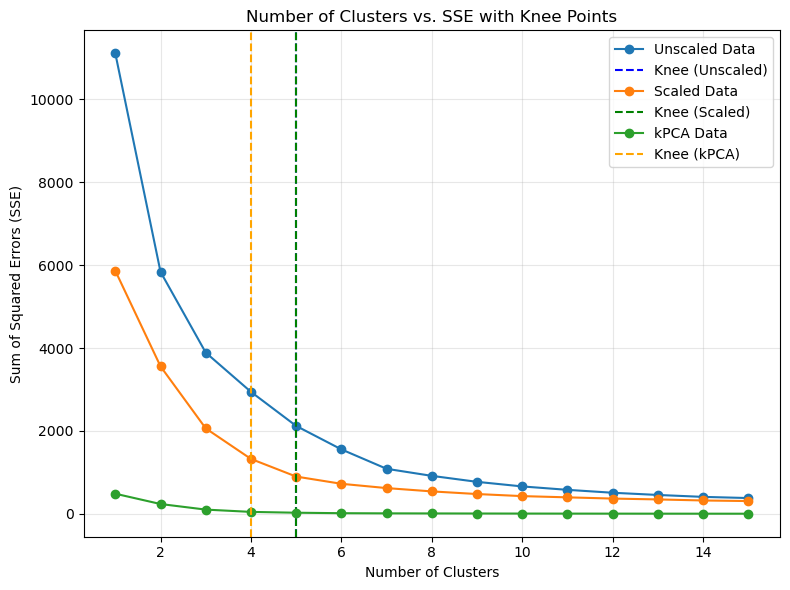

In [17]:
import numpy as np
from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt

# Define range of clusters to test
k_values = range(1, 16)  # Test from 1 to 10 clusters

# Initialize arrays to store SSE values
sse_unscaled = []
sse_scaled = []
sse_kpca = []

# Compute SSE for each k in the range
for k in k_values:
    # Unscaled data
    kmeans_unscaled = KMeans(n_clusters=k, random_state=42)
    kmeans_unscaled.fit(data[numerical_columns])
    sse_unscaled.append(kmeans_unscaled.inertia_)  # SSE for unscaled data

    # Scaled data
    kmeans_scaled = KMeans(n_clusters=k, random_state=42)
    kmeans_scaled.fit(data_scaled[numerical_columns])
    sse_scaled.append(kmeans_scaled.inertia_)  # SSE for scaled data

    # kPCA-transformed data
    kmeans_kpca = KMeans(n_clusters=k, random_state=42)
    kmeans_kpca.fit(data_kpca)
    sse_kpca.append(kmeans_kpca.inertia_)  # SSE for kPCA data

# Find the knee points for each dataset
knee_unscaled = KneeLocator(k_values, sse_unscaled, curve='convex', direction='decreasing')
knee_scaled = KneeLocator(k_values, sse_scaled, curve='convex', direction='decreasing')
knee_kpca = KneeLocator(k_values, sse_kpca, curve='convex', direction='decreasing')

# Print knee points
print("Optimal k for unscaled data:", knee_unscaled.knee)
print("Optimal k for scaled data:", knee_scaled.knee)
print("Optimal k for kPCA-transformed data:", knee_kpca.knee)

# Plot SSE vs. k with knee points marked
plt.figure(figsize=(8, 6))

# Plot unscaled data
plt.plot(k_values, sse_unscaled, label='Unscaled Data', marker='o')
plt.axvline(knee_unscaled.knee, color='blue', linestyle='--', label='Knee (Unscaled)')

# Plot scaled data
plt.plot(k_values, sse_scaled, label='Scaled Data', marker='o')
plt.axvline(knee_scaled.knee, color='orange', linestyle='--', label='Knee (Scaled)')

# Plot kPCA data
plt.plot(k_values, sse_kpca, label='kPCA Data', marker='o')
plt.axvline(knee_kpca.knee, color='green', linestyle='--', label='Knee (kPCA)')

plt.title('Number of Clusters vs. SSE with Knee Points')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


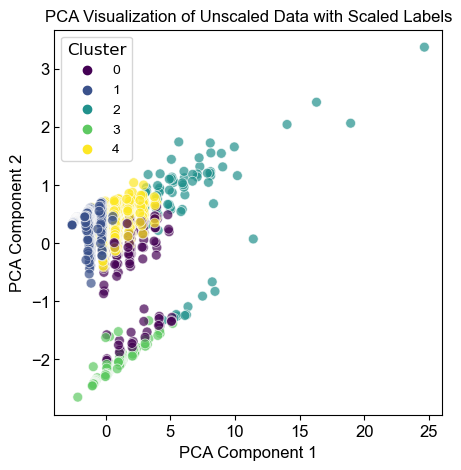

In [35]:
# Visualization for unscaled data with unscaled labels
plt.figure(figsize=(5, 5))
sns.scatterplot(data=pca_unscaled_df, x='PCA1', y='PCA2', hue=kmeans_labels_scaled, palette='viridis', s=50, alpha=0.7)
plt.title('PCA Visualization of Unscaled Data with Scaled Labels', fontsize=12, fontname="Arial")
plt.xlabel('PCA Component 1', fontsize=12, fontname="Arial")
plt.ylabel('PCA Component 2', fontsize=12, fontname="Arial")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
plt.show()

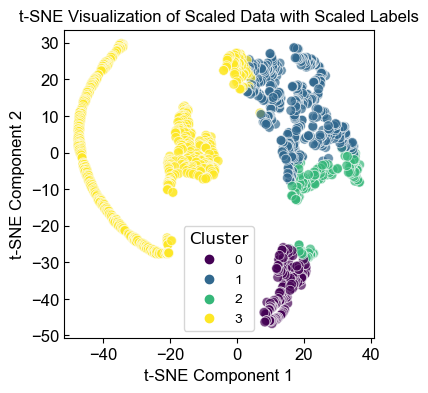

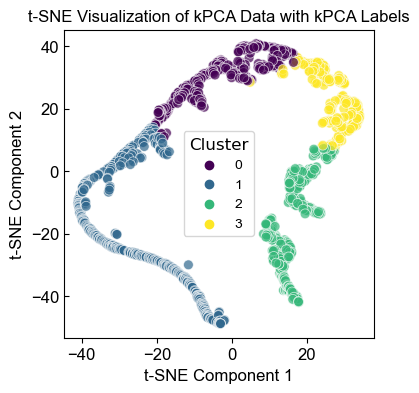

In [30]:
plt.figure(figsize=(4, 4))
sns.scatterplot(data=tsne_scaled_df, x='t-SNE1', y='t-SNE2', hue=kmeans_labels_scaled, palette='viridis', s=50, alpha=0.7)
plt.title('t-SNE Visualization of Scaled Data with Scaled Labels', fontsize=12, fontname="Arial")
plt.xlabel('t-SNE Component 1', fontsize=12, fontname="Arial")
plt.ylabel('t-SNE Component 2', fontsize=12, fontname="Arial")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\t-SNE Visualization of Scaled Data with Scaled Labels_k4.jpeg", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(4, 4))
sns.scatterplot(data=tsne_kpca_df, x='t-SNE1', y='t-SNE2', hue=kmeans_labels_kpca, palette='viridis', s=50, alpha=0.7)
plt.title('t-SNE Visualization of kPCA Data with kPCA Labels', fontsize=12, fontname="Arial")
plt.xlabel('t-SNE Component 1', fontsize=12, fontname="Arial")
plt.ylabel('t-SNE Component 2', fontsize=12, fontname="Arial")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\t-SNE Visualization of kPCA Data with kPCA Labels_k4.jpeg", dpi=300, bbox_inches="tight")
plt.show()

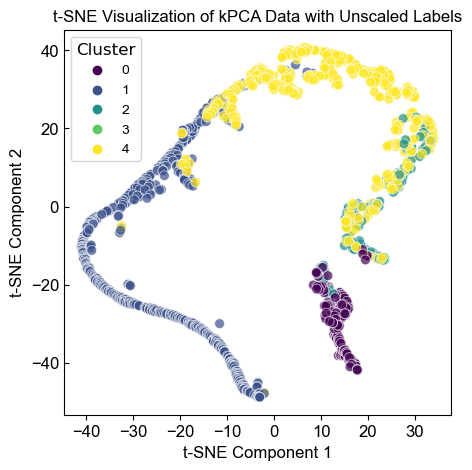

In [37]:
plt.figure(figsize=(5, 5))
sns.scatterplot(data=tsne_kpca_df, x='t-SNE1', y='t-SNE2', hue=kmeans_labels_unscaled, palette='viridis', s=50, alpha=0.7)
plt.title('t-SNE Visualization of kPCA Data with Unscaled Labels', fontsize=12, fontname="Arial")
plt.xlabel('t-SNE Component 1', fontsize=12, fontname="Arial")
plt.ylabel('t-SNE Component 2', fontsize=12, fontname="Arial")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
#plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\t-SNE Visualization of Unscaled Data.jpeg", dpi=300, bbox_inches="tight")
plt.show()

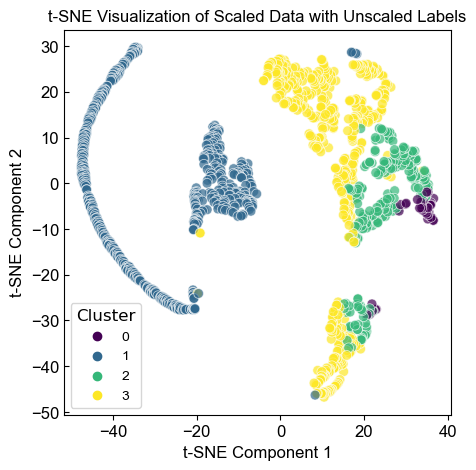

In [32]:
plt.figure(figsize=(5, 5))
sns.scatterplot(data=tsne_scaled_df, x='t-SNE1', y='t-SNE2', hue=kmeans_labels_unscaled, palette='viridis', s=50, alpha=0.7)
plt.title('t-SNE Visualization of Scaled Data with Unscaled Labels', fontsize=12, fontname="Arial")
plt.xlabel('t-SNE Component 1', fontsize=12, fontname="Arial")
plt.ylabel('t-SNE Component 2', fontsize=12, fontname="Arial")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
#plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\t-SNE Visualization of Unscaled Data.jpeg", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
# Visualization using t-SNE on unscaled data
tsne_unscaled = TSNE(n_components=2, random_state=42)
data_tsne_unscaled = tsne_unscaled.fit_transform(data)
tsne_unscaled_df = pd.DataFrame(data_tsne_unscaled, columns=['t-SNE1', 't-SNE2'])
tsne_unscaled_df['Cluster'] = kmeans_labels_unscaled  # Add cluster labels

plt.figure(figsize=(4, 4))
sns.scatterplot(data=tsne_unscaled_df, x='t-SNE1', y='t-SNE2', hue='Cluster', palette='viridis', s=50, alpha=0.7)
plt.title('t-SNE Visualization of Unscaled Data', fontsize=12, fontname="Arial")
plt.xlabel('t-SNE Component 1', fontsize=12, fontname="Arial")
plt.ylabel('t-SNE Component 2', fontsize=12, fontname="Arial")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
plt.show()


ValueError: could not convert string to float: 'pH_10'

In [18]:
# Visualization using t-SNE on scaled data
tsne_scaled = TSNE(n_components=2, random_state=42)
data_tsne_scaled = tsne_scaled.fit_transform(data_scaled)
tsne_scaled_df = pd.DataFrame(data_tsne_scaled, columns=['t-SNE1', 't-SNE2'])
tsne_scaled_df['Cluster'] = kmeans_labels_unscaled


plt.figure(figsize=(4, 4))
sns.scatterplot(data=tsne_scaled_df, x='t-SNE1', y='t-SNE2', hue='Cluster', palette='viridis', s=50, alpha=0.7)
plt.title('t-SNE Visualization of Scaled Data', fontsize=12, fontname="Arial")
plt.xlabel('t-SNE Component 1', fontsize=12, fontname="Arial")
plt.ylabel('t-SNE Component 2', fontsize=12, fontname="Arial")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\t-SNE Visualization of Scaled Data.jpeg", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


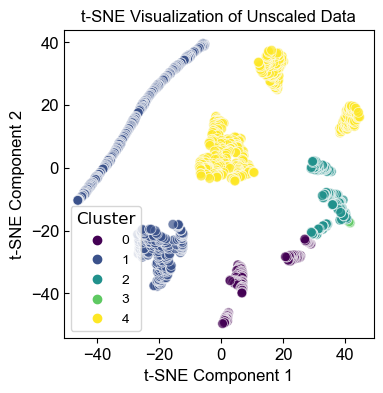

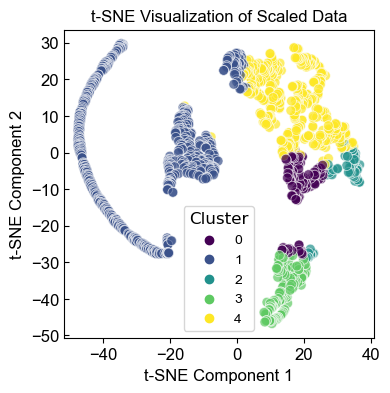

C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


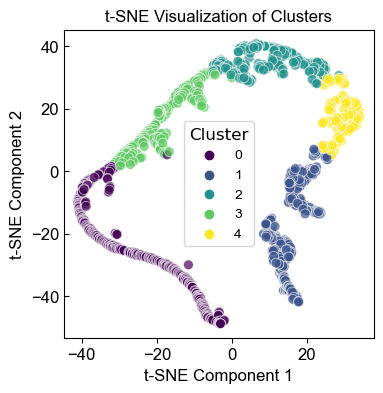

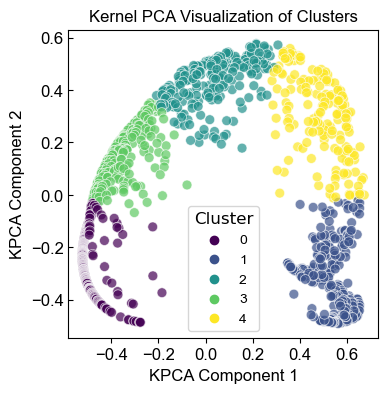

In [19]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'data' is a pandas DataFrame for better column manipulation
# Uncomment and adapt the line below to define your data
data = pd.DataFrame(data)

numerical_columns = columns 
data = data[numerical_columns]

# Parameters
data_columns = data.columns  # Assume all columns are included initially
exclude_columns = ['Treatment']  # List of column names to exclude from z-transform

# Separate excluded columns and apply z-transform
included_columns = [col for col in data_columns if col not in exclude_columns]
scaler = StandardScaler()
data_scaled = data.copy()
data_scaled[included_columns] = scaler.fit_transform(data[included_columns])

# K-Means Clustering
n_clusters = 5  # Define the number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels_unscaled = kmeans.fit_predict(data)
kmeans_labels_scaled = kmeans.fit_predict(data_scaled)

# Visualization using t-SNE on unscaled data
tsne_unscaled = TSNE(n_components=2, random_state=42)
data_tsne_unscaled = tsne_unscaled.fit_transform(data)
tsne_unscaled_df = pd.DataFrame(data_tsne_unscaled, columns=['t-SNE1', 't-SNE2'])
tsne_unscaled_df['Cluster'] = kmeans_labels_unscaled

plt.figure(figsize=(4, 4))
sns.scatterplot(data=tsne_unscaled_df, x='t-SNE1', y='t-SNE2', hue='Cluster', palette='viridis', s=50, alpha=0.7)
plt.title('t-SNE Visualization of Unscaled Data', fontsize=12, fontname="Arial")
plt.xlabel('t-SNE Component 1', fontsize=12, fontname="Arial")
plt.ylabel('t-SNE Component 2', fontsize=12, fontname="Arial")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\t-SNE Visualization of Unscaled Data.jpeg", dpi=300, bbox_inches="tight")
plt.show()

# Visualization using t-SNE on scaled data
tsne_scaled = TSNE(n_components=2, random_state=42)
data_tsne_scaled = tsne_scaled.fit_transform(data_scaled)
tsne_scaled_df = pd.DataFrame(data_tsne_scaled, columns=['t-SNE1', 't-SNE2'])
tsne_scaled_df['Cluster'] = kmeans_labels_scaled

plt.figure(figsize=(4, 4))
sns.scatterplot(data=tsne_scaled_df, x='t-SNE1', y='t-SNE2', hue='Cluster', palette='viridis', s=50, alpha=0.7)
plt.title('t-SNE Visualization of Scaled Data', fontsize=12, fontname="Arial")
plt.xlabel('t-SNE Component 1', fontsize=12, fontname="Arial")
plt.ylabel('t-SNE Component 2', fontsize=12, fontname="Arial")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\t-SNE Visualization of Scaled Data.jpeg", dpi=300, bbox_inches="tight")
plt.show()

# Kernel PCA with RBF kernel
kernel_pca = KernelPCA(n_components=2, kernel='rbf')
data_kpca = kernel_pca.fit_transform(data_scaled)
kpca_df = pd.DataFrame(data_kpca, columns=['KPCA1', 'KPCA2'])
kpca_df['Cluster'] = kmeans.fit_predict(data_kpca)

# Visualization using t-SNE
tsne = TSNE(n_components=2, random_state=42)
data_tsne = tsne.fit_transform(data_kpca)
tsne_df = pd.DataFrame(data_tsne, columns=['t-SNE1', 't-SNE2'])
tsne_df['Cluster'] = kpca_df['Cluster']

plt.figure(figsize=(4, 4))
sns.scatterplot(data=tsne_df, x='t-SNE1', y='t-SNE2', hue='Cluster', palette='viridis', s=50, alpha=0.7)
plt.title('t-SNE Visualization of Clusters', fontsize=12, fontname="Arial")
plt.xlabel('t-SNE Component 1', fontsize=12, fontname="Arial")
plt.ylabel('t-SNE Component 2', fontsize=12, fontname="Arial")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\t-SNE Visualization of Clusters.jpeg", dpi=300, bbox_inches="tight")
plt.show()

# Visualization using PCA for comparison
plt.figure(figsize=(4, 4))
sns.scatterplot(data=kpca_df, x='KPCA1', y='KPCA2', hue='Cluster', palette='viridis', s=50, alpha=0.7)
plt.title('Kernel PCA Visualization of Clusters', fontsize=12, fontname="Arial")
plt.xlabel('KPCA Component 1', fontsize=12, fontname="Arial")
plt.ylabel('KPCA Component 2', fontsize=12, fontname="Arial")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\Kernel PCA Visualization of Clusters.jpeg", dpi=300, bbox_inches="tight")
plt.show()

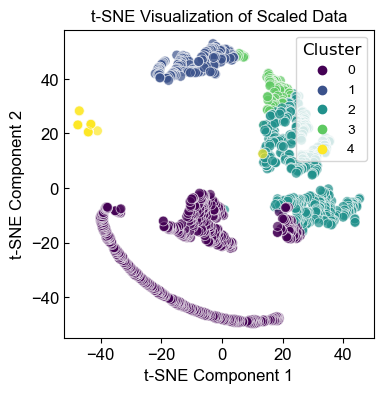

C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [20]:
# Visualization using t-SNE on scaled data
tsne_scaled = TSNE(n_components=2, random_state=42)
data_tsne_scaled = tsne_scaled.fit_transform(data_scaled)
tsne_scaled_df = pd.DataFrame(data_tsne_scaled, columns=['t-SNE1', 't-SNE2'])
tsne_scaled_df['Cluster'] = kmeans_labels_scaled

plt.figure(figsize=(4, 4))
sns.scatterplot(data=tsne_scaled_df, x='t-SNE1', y='t-SNE2', hue='Cluster', palette='viridis', s=50, alpha=0.7)
plt.title('t-SNE Visualization of Scaled Data', fontsize=12, fontname="Arial")
plt.xlabel('t-SNE Component 1', fontsize=12, fontname="Arial")
plt.ylabel('t-SNE Component 2', fontsize=12, fontname="Arial")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\t-SNE Visualization of Scaled Data.jpeg", dpi=300, bbox_inches="tight")
plt.show()

# Kernel PCA with RBF kernel
kernel_pca = KernelPCA(n_components=2, kernel='rbf')
data_kpca = kernel_pca.fit_transform(data_scaled)
kpca_df = pd.DataFrame(data_kpca, columns=['KPCA1', 'KPCA2'])
kpca_df['Cluster'] = kmeans.fit_predict(data_kpca)

In [21]:
import numpy as np
import pandas as pd
from sklearn.decomposition import KernelPCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters for KPCA
n_components = 5  # Choose the number of components for KPCA
kernel = 'rbf'  # Use the radial basis function (RBF) kernel, or other kernels like 'linear'

# Apply KPCA
kpca = KernelPCA(n_components=n_components, kernel=kernel)
data_kpca = kpca.fit_transform(data)

# Apply scaling (if not already scaled)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Parameters for k-means clustering
k_values = range(1, 16)
sse_unscaled = []
sse_scaled = []
sse_kpca = []

# Compute SSE for k-means on unscaled, scaled, and KPCA-transformed data
for k in k_values:
    kmeans_unscaled = KMeans(n_clusters=k, random_state=42).fit(data)
    sse_unscaled.append(kmeans_unscaled.inertia_)

    kmeans_scaled = KMeans(n_clusters=k, random_state=42).fit(data_scaled)
    sse_scaled.append(kmeans_scaled.inertia_)

    kmeans_kpca = KMeans(n_clusters=k, random_state=42).fit(data_kpca)
    sse_kpca.append(kmeans_kpca.inertia_)

# Normalize SSE values for better comparison
sse_unscaled_norm = np.array(sse_unscaled) / max(sse_unscaled)
sse_scaled_norm = np.array(sse_scaled) / max(sse_scaled)
sse_kpca_norm = np.array(sse_kpca) / max(sse_kpca)

# Find the knee points for each curve
knee_unscaled = KneeLocator(k_values, sse_unscaled_norm, curve="convex", direction="decreasing").knee
knee_scaled = KneeLocator(k_values, sse_scaled_norm, curve="convex", direction="decreasing").knee
knee_kpca = KneeLocator(k_values, sse_kpca_norm, curve="convex", direction="decreasing").knee

# Create a DataFrame for plotting
sse_df = pd.DataFrame({
    'K': k_values,
    'Unscaled': sse_unscaled_norm,
    'Scaled': sse_scaled_norm,
    'KPCA': sse_kpca_norm
})
sse_df = sse_df.melt(id_vars='K', var_name='Data Type', value_name='Normalized SSE')

# Plot SSE values
plt.figure(figsize=(5, 5))
sns.lineplot(data=sse_df, x='K', y='Normalized SSE', hue='Data Type', marker='o')

# Add vertical lines for knee points
plt.axvline(x=knee_unscaled, color='blue', linestyle='--', label=f'Unscaled Knee (K={knee_unscaled})')
plt.axvline(x=knee_scaled, color='orange', linestyle='--', label=f'Scaled Knee (K={knee_scaled})')
plt.axvline(x=knee_kpca, color='green', linestyle='--', label=f'KPCA Knee (K={knee_kpca})')

# Customize the plot
plt.title('K Values vs. Normalized SSE for Different Data Transformations', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12, fontname='Arial')
plt.ylabel('Normalized SSE', fontsize=12, fontname='Arial')
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Data Type', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
plt.grid(visible=True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()

# Print knee points
print(f"Knee point for Unscaled data: K={knee_unscaled}")
print(f"Knee point for Scaled data: K={knee_scaled}")
print(f"Knee point for KPCA-transformed data: K={knee_kpca}")


ValueError: could not convert string to float: 'pH_10'

# Below this point is trial and error code:

In [16]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Load Excel file
file_path = r'C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Dispersed Cells Cluster Size and Morphology Data\DispersedCells_ClusterSizeMorphology_GIGADATA.xlsx'  # Update this with your actual file path
sheet_names = ["Untreated", "NaIO4", "Proteinase_K", "DNase", "pH_10"]
columns = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]

# Initialize empty DataFrames
all_data = pd.DataFrame()
pristine_data = pd.DataFrame()

# Load, process, and split data from all sheets
for sheet in sheet_names:
    # Load data from the current sheet
    data = pd.read_excel(file_path, sheet_name=sheet, usecols=columns)
    data['Treatment'] = sheet  # Add a column to identify treatment condition

    # Convert columns to numeric, coercing errors
    for column in columns:
        data[column] = pd.to_numeric(data[column], errors='coerce')

    # Drop rows with NaN values introduced during coercion
    data = data.dropna()

# Parameters
data_columns = data.columns  # Assume all columns are included initially
exclude_columns = ['Treatment']  # List of column names to exclude from z-transform

# Separate excluded columns and apply z-transform
included_columns = [col for col in data_columns if col not in exclude_columns]
scaler = StandardScaler()
data_scaled_array = scaler.fit_transform(data[included_columns])  # Scale numeric columns

# Combine scaled data with the "Treatment" column
treatment_column = data['Treatment'].values.reshape(-1, 1)  # Ensure it is a 2D array
data_scaled_combined = np.hstack((data_scaled_array, treatment_column))

# Create a DataFrame with the original columns
data_scaled = pd.DataFrame(data_scaled_combined, columns=included_columns + exclude_columns)
data_scaled = data_scaled.dropna()
data = data.dropna()

# Display the original and scaled data for verification
print("Original Data:")
print(data)

print("\nScaled Data:")
print(data_scaled.head())

Original Data:


KeyError: 200

In [23]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'data', 'data_scaled', and 'data_kpca' are defined from the previous script

# Parameters
k_values = range(1, 16)
sse_unscaled = []
sse_scaled = []
sse_kpca = []

# Compute SSE for k-means on unscaled, scaled, and KPCA-transformed data
for k in k_values:
    kmeans_unscaled = KMeans(n_clusters=k, random_state=42).fit(data)
    sse_unscaled.append(kmeans_unscaled.inertia_)

    kmeans_scaled = KMeans(n_clusters=k, random_state=42).fit(data_scaled)
    sse_scaled.append(kmeans_scaled.inertia_)

    kmeans_kpca = KMeans(n_clusters=k, random_state=42).fit(data_kpca)
    sse_kpca.append(kmeans_kpca.inertia_)

# Normalize SSE values for better comparison
sse_unscaled_norm = np.array(sse_unscaled) / max(sse_unscaled)
sse_scaled_norm = np.array(sse_scaled) / max(sse_scaled)
sse_kpca_norm = np.array(sse_kpca) / max(sse_kpca)

# Find the knee points for each curve
knee_unscaled = KneeLocator(k_values, sse_unscaled_norm, curve="convex", direction="decreasing").knee
knee_scaled = KneeLocator(k_values, sse_scaled_norm, curve="convex", direction="decreasing").knee
knee_kpca = KneeLocator(k_values, sse_kpca_norm, curve="convex", direction="decreasing").knee

# Create a DataFrame for plotting
sse_df = pd.DataFrame({
    'K': k_values,
    'Unscaled': sse_unscaled_norm,
    'Scaled': sse_scaled_norm,
    'KPCA': sse_kpca_norm
})
sse_df = sse_df.melt(id_vars='K', var_name='Data Type', value_name='Normalized SSE')

# Plot SSE values
plt.figure(figsize=(10, 6))
sns.lineplot(data=sse_df, x='K', y='Normalized SSE', hue='Data Type', marker='o')
plt.axvline(x=knee_unscaled, color='blue', linestyle='--', label=f'Unscaled Knee (K={knee_unscaled})')
plt.axvline(x=knee_scaled, color='orange', linestyle='--', label=f'Scaled Knee (K={knee_scaled})')
plt.axvline(x=knee_kpca, color='green', linestyle='--', label=f'KPCA Knee (K={knee_kpca})')
plt.title('K Values vs. Normalized SSE for Different Data Transformations', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12, fontname='Arial')
plt.ylabel('Normalized SSE', fontsize=12, fontname='Arial')
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Data Type', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
plt.grid(visible=True, linestyle='--', alpha=0.6)
plt.show()

# Print knee points
print(f"Knee point for Unscaled data: K={knee_unscaled}")
print(f"Knee point for Scaled data: K={knee_scaled}")
print(f"Knee point for KPCA-transformed data: K={knee_kpca}")


ValueError: could not convert string to float: 'pH_10'

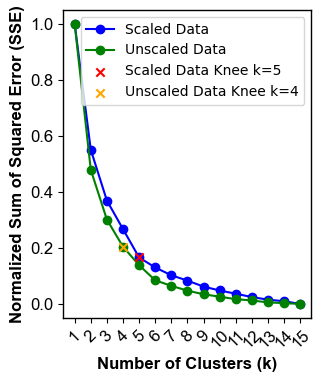

Optimal number of clusters (k) for Scaled Data: 5
Optimal number of clusters (k) for Unscaled Data: 4


In [6]:
from kneed import KneeLocator
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Define the range of k-values
k_values = range(1, 16)  # K-values from 1 to 5

# Ensure you exclude categorical columns like 'Treatment' from the clustering
numerical_columns = columns  # List of numerical feature columns (excluding categorical ones)

# Scale the pristine data, excluding categorical columns
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[numerical_columns])
data = data[numerical_columns]

# Initialize lists to store inertia (error) values for the data
inertia_data = []
inertia_data_scaled = []

# Calculate inertia for both datasets across k-values
for k in k_values:
    # Perform K-Means on scaled data 
    kmeans_data_scaled = KMeans(n_clusters=k, n_init=10, random_state=0)
    kmeans_data_scaled.fit(data_scaled)  # scaled data

    # Calculate inertia for scaled data
    inertia_data_scaled.append(kmeans_data_scaled.inertia_)
    
    # Perform K-Means on unscaled data 
    kmeans_data = KMeans(n_clusters=k, n_init=10, random_state=0)
    kmeans_data.fit(data)  # unscaled data
    
    # Calculate inertia for unscaled data
    inertia_data.append(kmeans_data.inertia_)

# Normalize the inertia values to be between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))

# Reshape the inertia lists to 2D arrays for scaling
inertia_data = scaler.fit_transform(np.array(inertia_data).reshape(-1, 1)).flatten()
inertia_data_scaled = scaler.fit_transform(np.array(inertia_data_scaled).reshape(-1, 1)).flatten()

# Plotting the comparison of normalized inertia values for both datasets
plt.figure(figsize=(3.2, 4))

# Plot normalized inertia for scaled data
plt.plot(k_values, inertia_data_scaled, marker='o', linestyle='-', color='blue', label='Scaled Data')

# Plot normalized inertia for unscaled data
plt.plot(k_values, inertia_data, marker='o', linestyle='-', color='green', label='Unscaled Data')

# Customize plot
plt.xlabel('Number of Clusters (k)', fontsize=12, fontname='Arial', fontweight='bold')
plt.ylabel('Normalized Sum of Squared Error (SSE)', fontsize=12, fontname='Arial', fontweight='bold')
plt.xticks(np.arange(1, 16, 1), fontsize=12, fontname='Arial', rotation=45)
plt.yticks(fontsize=12, fontname='Arial')

# Add a 1pt frame around the plot
plt.gca().spines['top'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['left'].set_linewidth(1)

# Plot the elbow/knee point
kneedle_data_scaled = KneeLocator(k_values, inertia_data_scaled, curve='convex', direction='decreasing')
kneedle_data = KneeLocator(k_values, inertia_data, curve='convex', direction='decreasing')

# Add the knee point to the plot
plt.scatter(kneedle_data_scaled.elbow, kneedle_data_scaled.elbow_y, color='red', marker='x', zorder=4, label=f'Scaled Data Knee k={kneedle_data_scaled.elbow}')
plt.scatter(kneedle_data.elbow, kneedle_data.elbow_y, color='orange', marker='x', zorder=5, label=f'Unscaled Data Knee k={kneedle_data.elbow}')

# Add legend
plt.legend()

# Save and show the plot
#plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\k-means_comparison_train_pristine_normalized.jpeg", dpi=300, bbox_inches="tight")
plt.show()

# Print optimal k-values for both datasets
print(f"Optimal number of clusters (k) for Scaled Data: {kneedle_data_scaled.elbow}")
print(f"Optimal number of clusters (k) for Unscaled Data: {kneedle_data.elbow}")


In [7]:
data = pd.DataFrame(data)
print(data.head())
data_scaled = pd.DataFrame(data_scaled)
print(data_scaled.head())

   N_cl  Euclid_2R  Shape_anisotropy_index  Asphericity_index
0    20   6.902680                0.853631          -1.157848
1     9   6.652105                0.990215          -1.938684
2    29   6.011283                0.742969          -1.022562
3    23   5.717284                0.478107          -0.520069
4    15   5.514374                0.910992           0.432992
           0         1         2         3
0   6.808133  6.078667 -0.980075  0.096907
1   2.078006  5.747918  0.463260 -0.733784
2  10.678237  4.902057 -2.149477  0.240831
3   8.098168  4.513990 -4.948381  0.775409
4   4.658075  4.246157 -0.373912  1.789322


In [20]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, KernelPCA

# Set the number of clusters
num_clusters = 5  # Adjust the number of clusters if needed

# Apply kernel PCA with radial basis function (RBF kernel)
kpca = KernelPCA(n_components=min(len(scaled_data_numerical), 10), kernel='rbf', gamma=15)  # Adjust gamma as needed
data_kpca = kpca.fit_transform(scaled_data_numerical)

# Perform k-means clustering on the combined data
kmeans = KMeans(n_clusters=num_clusters, n_init=10, random_state=0)
kmeans.fit(scaled_data_numerical)

# Add cluster labels to the original DataFrame for reference
cluster_labels = kmeans.labels_

# Visualize the clustering results
# For visualization, we'll reduce dimensions to 2D using t-SNE
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(scaled_data_numerical)

# Reduce dimensions to 2D using PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_data_numerical)

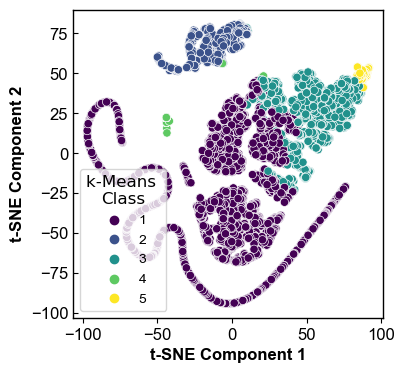

In [32]:
import seaborn as sns

# Create a figure with a specified size (4x4 inches) using subplots
fig, ax = plt.subplots(figsize=(4, 4))  

# Plot the t-SNE results with clusters
scatter = sns.scatterplot(
    x=tsne_results[:, 0], 
    y=tsne_results[:, 1], 
    hue=cluster_labels, 
    palette="viridis", 
    legend="full",
    ax=ax  # Specify the axis for the plot
)

# Set plot title and axis labels with the required font and style
# plt.title('K-Means Clustering with t-SNE Visualization', fontsize=12, fontname='Times New Roman')
plt.xlabel('t-SNE Component 1', fontsize=12, fontname='Arial', fontweight='bold')
plt.ylabel('t-SNE Component 2', fontsize=12, fontname='Arial', fontweight='bold')

# Customize tick label font
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)

# Set axis limits
#plt.xlim(-50, 50)
#plt.ylim(-50, 50)

# Add a 1 pt frame around the plot
plt.gca().spines['top'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['left'].set_linewidth(1)

# Get legend handles and labels
handles, labels = scatter.get_legend_handles_labels()

# Update the labels (optional)
new_labels = [str(int(label) + 1) for label in labels if label.isdigit()]

# Apply the customized legend settings
legend = plt.legend(
    handles,
    new_labels,
    title="k-Means \nClass",  # Title with line breaks for wrapping
    title_fontsize=12,
    fontsize=12,
    prop={"family": "Arial"},
    loc="lower left"
)

# Center the title
legend.get_title().set_horizontalalignment('center')

# Left-align the legend entries
for text in legend.get_texts():
    text.set_horizontalalignment('left')

# Optional: Print or view cluster centroids and analyze them
# Assuming `kmeans` is a fitted KMeans object from sklearn
# print("Cluster Centroids:\n", kmeans.cluster_centers_)

# Save the plot
plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\t-sne_plot_scaled_data.jpeg", dpi=300, bbox_inches="tight")

# Display the plot
plt.show()


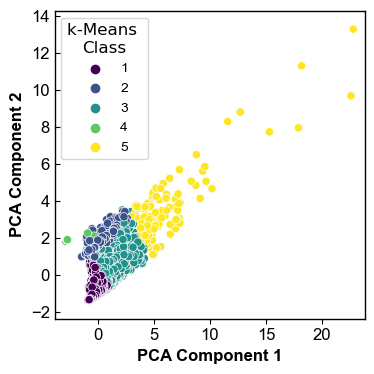

In [36]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure for the PCA visualization
fig, ax = plt.subplots(figsize=(4, 4))

# Plot the PCA results with clusters
scatter = sns.scatterplot(
    x=pca_results[:, 0], 
    y=pca_results[:, 1], 
    hue=cluster_labels, 
    palette="viridis", 
    legend="full",
    ax=ax
)

# Set plot title and axis labels
#plt.title('K-Means Clustering with PCA Visualization', fontsize=12, fontname='Arial', fontweight='bold')
plt.xlabel('PCA Component 1', fontsize=12, fontname='Arial', fontweight='bold')
plt.ylabel('PCA Component 2', fontsize=12, fontname='Arial', fontweight='bold')

# Customize tick labels and axis properties
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)

# Set axis limits
plt.xlim(pca_results[:, 0].min() -1, pca_results[:, 0].max()+1)
plt.ylim(pca_results[:, 1].min() -1, pca_results[:, 1].max()+1)

# Add a 1 pt frame around the plot
plt.gca().spines['top'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['left'].set_linewidth(1)

# Get legend handles and labels
handles, labels = scatter.get_legend_handles_labels()

# Update the labels (optional)
new_labels = [str(int(label) + 1) for label in labels if label.isdigit()]

# Apply customized legend settings
legend = plt.legend(
    handles,
    new_labels,
    title="k-Means \nClass",  # Title with line breaks for wrapping
    title_fontsize=12,
    fontsize=12,
    prop={"family": "Arial"},
    loc="upper left"
)

# Center the legend title
legend.get_title().set_horizontalalignment('center')

# Left-align the legend entries
for text in legend.get_texts():
    text.set_horizontalalignment('left')

# Save the plot (optional)
plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\pca_plot_scaled_data.jpeg", dpi=300, bbox_inches="tight")

# Display the plot
plt.show()


In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load Excel file
file_path = r'C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Dispersed Cells Cluster Size and Morphology Data\DispersedCells_ClusterSizeMorphology_GIGADATA.xlsx'  # Update this with your actual file path
sheet_names = ["Untreated", "NaIO4", "Proteinase_K", "DNase", "pH_10"]
columns = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]

# Initialize empty DataFrames
all_data = pd.DataFrame()
pristine_data = pd.DataFrame()

# Load, process, and split data from all sheets
for sheet in sheet_names:
    # Load data from the current sheet
    data = pd.read_excel(file_path, sheet_name=sheet, usecols=columns)
    data['Treatment'] = sheet  # Add a column to identify treatment condition

    # Convert columns to numeric, coercing errors
    for column in columns:
        data[column] = pd.to_numeric(data[column], errors='coerce')

    # Drop rows with NaN values introduced during coercion
    data = data.dropna()

# Standardize the training data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[columns])

# Display the pristine and training data for verification
print("Data:")
print(data.head())

Data:
   N_cl  Euclid_2R  Shape_anisotropy_index  Asphericity_index Treatment
0    20   6.902680                0.853631          -1.157848     pH_10
1     9   6.652105                0.990215          -1.938684     pH_10
2    29   6.011283                0.742969          -1.022562     pH_10
3    23   5.717284                0.478107          -0.520069     pH_10
4    15   5.514374                0.910992           0.432992     pH_10


In [13]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA

# Assuming 'data' is already defined
data = pd.DataFrame(data)

# Separate numerical and non-numerical columns
numerical_columns = data.select_dtypes(include=['number'])
non_numerical_columns = data.select_dtypes(exclude=['number'])

# Apply z-transform to numerical columns
scaler = StandardScaler()
data_numerical_scaled = pd.DataFrame(scaler.fit_transform(numerical_columns), columns=numerical_columns.columns)

# Rejoin the non-numerical columns
data_scaled = pd.concat([data_numerical_scaled, non_numerical_columns], axis=1)

# Remove NaN values from data_scaled
data_scaled = data_scaled.dropna()

# Perform Kernel PCA
n_components = 2  # Set the number of components for KernelPCA (adjust as needed)
kernel = 'rbf'  # Set the kernel for KernelPCA (adjust as needed)
kpca = KernelPCA(n_components=n_components, kernel=kernel)
data_numerical_kpca = pd.DataFrame(kpca.fit_transform(numerical_columns), columns=[f'PC{i+1}' for i in range(n_components)])

# Rejoin the non-numerical columns
data_kpca = pd.concat([data_numerical_kpca, non_numerical_columns], axis=1)

# Remove NaN values from data_kpca
data_kpca = data_kpca.dropna()

# Print the results
print(data_scaled.head())
print(data_kpca.head())


        N_cl  Euclid_2R  Shape_anisotropy_index  Asphericity_index Treatment
0   6.808133   6.078667               -0.980075           0.096907     pH_10
1   2.078006   5.747918                0.463260          -0.733784     pH_10
2  10.678237   4.902057               -2.149477           0.240831     pH_10
3   8.098168   4.513990               -4.948381           0.775409     pH_10
4   4.658075   4.246157               -0.373912           1.789322     pH_10
        PC1       PC2 Treatment
0 -0.171709  0.318384     pH_10
1 -0.179898  0.340283     pH_10
2 -0.171532  0.317840     pH_10
3 -0.171573  0.317964     pH_10
4 -0.172585  0.321164     pH_10


In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.cluster import KMeans

# Assuming `data`, `data_scaled`, and `data_kpca` are DataFrames

# Array of Treatments
treatments = ["Untreated", "NaIO4", "Proteinase_K", "DNase", "pH_10"]

# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Function to calculate cluster statistics
def calculate_cluster_stats(df, labels, treatments):
    cluster_stats = []
    for cluster_id in np.unique(labels):
        cluster_data = df[labels == cluster_id]
        size = len(cluster_data)
        feature_stats = cluster_data.describe().to_dict()
        treatment_counts = cluster_data['Treatment'].value_counts().reindex(treatments, fill_value=0).to_dict()

        cluster_stats.append({
            "Cluster": cluster_id,
            "Size": size,
            "Feature_Statistics": feature_stats,
            "Treatment_Counts": treatment_counts
        })
    return cluster_stats

# Perform clustering and collect statistics for each dataset
results = {}
for dataset_name, dataset in zip(["data", "data_scaled", "data_kpca"], [data, data_scaled, data_kpca]):
    dataset_stats = []
    
    for fold, (train_index, test_index) in enumerate(kf.split(dataset)):
        train_data = dataset.iloc[train_index]
        test_data = dataset.iloc[test_index]

        # Apply k-means clustering
        kmeans = KMeans(n_clusters=5, random_state=42)
        kmeans.fit(train_data.drop(columns="Treatment"))
        labels = kmeans.predict(test_data.drop(columns="Treatment"))

        # Calculate cluster statistics
        fold_stats = calculate_cluster_stats(test_data, labels, treatments)
        dataset_stats.append({"Fold": fold + 1, "Cluster_Stats": fold_stats})

    results[dataset_name] = dataset_stats

    
output_file = r'C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Dispersed Cells Cluster Size and Morphology Data\scaled_unscaled_kpca_cluster_results.xlsx'
    
# Export results to Excel
with pd.ExcelWriter(output_file) as writer:
    for dataset_name, stats in results.items():
        all_folds_data = []
        for fold_info in stats:
            fold = fold_info['Fold']
            for cluster_info in fold_info['Cluster_Stats']:
                cluster_id = cluster_info['Cluster']
                size = cluster_info['Size']
                feature_stats = cluster_info['Feature_Statistics']
                treatment_counts = cluster_info['Treatment_Counts']

                row = {
                    "Dataset": dataset_name,
                    "Fold": fold,
                    "Cluster": cluster_id,
                    "Size": size,
                }
                row.update({f"Feature_{k}": v for k, v in feature_stats.items()})
                row.update({f"Treatment_{k}": v for k, v in treatment_counts.items()})

                all_folds_data.append(row)

        df = pd.DataFrame(all_folds_data)
        df.to_excel(writer, sheet_name=dataset_name, index=False)

print("Results have been exported to 'clustering_results.xlsx'")


C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarni

Results have been exported to 'clustering_results.xlsx'


C:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
